In [1]:
using Distributions
using StatsFuns
using CairoMakie
using JLD2
using EM
filepath = ".."
include("../code/util.jl")

ArgumentError: ArgumentError: Package Distributions not found in current path.
- Run `import Pkg; Pkg.add("Distributions")` to install the Distributions package.

# Beta Bernoulli Model

We're going to present an alternate learning mechanism to the HMM, a Beta Bernoulli learner

## Model Details
The value at port $i$ is represented by two variables, $\alpha_i$ and $\beta_i$, which respectively count the number of successes and failures at each port.

The mean is then given by $\mu_i = \frac{\alpha_i + 1}{\alpha_i + \beta_i + 2}$, where the offsets of 1 and 2 correspond to a distribution of $Beta(1,1)$ at baseline.

This baseline $Beta(1,1)$ is a uniform distribution over $[0,1]$ and has a mean of $\mu=0.5$



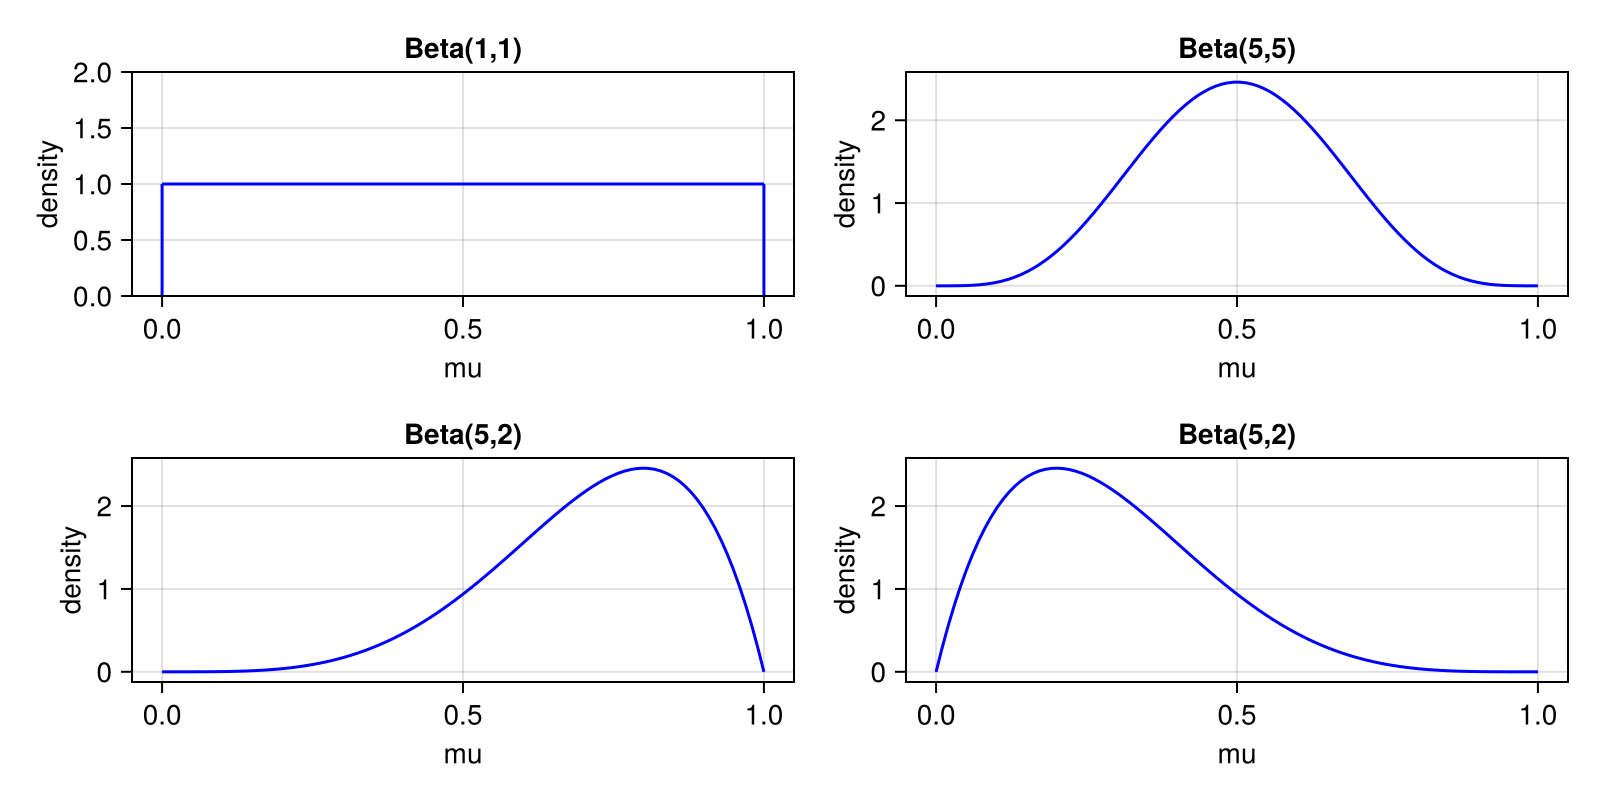

In [2]:
x = range(0, 1, length=100)

f = Figure(size = (800, 400))
ax = Axis(f[1, 1], xlabel = "mu", ylabel = "density", title="Beta(1,1)")
b11 = pdf(Beta(1,1), x)
lines!(ax, x, b11, color = :blue)
vlines!(ax, [0.0], color = :blue, ymin=0.0, ymax=0.5)
vlines!(ax, [1.0], color = :blue, ymin=0.0, ymax=0.5)
ax = Axis(f[1, 2], xlabel = "mu", ylabel = "density", title="Beta(5,5)")
b55 = pdf(Beta(5,5), x)
lines!(ax, x, b55, color = :blue)
ax = Axis(f[2, 1], xlabel = "mu", ylabel = "density", title="Beta(5,2)")
b52 = pdf(Beta(5,2), x)
lines!(ax, x, b52, color = :blue)
ax = Axis(f[2, 2], xlabel = "mu", ylabel = "density", title="Beta(5,2)")
b25 = pdf(Beta(2,5), x)
lines!(ax, x, b25, color = :blue)
f

After each trial, updating is performed as:
- $\alpha_i \leftarrow \alpha_i + r$
- $\beta_i \leftarrow \beta_i + (1 - r)$

This model gives us an easy estimation of variance / uncertainty - variance of the true mean is given by $\frac{(\alpha + 1)(\beta + 1)}{(\alpha + \beta + 2)^2(\alpha + \beta + 3)}$

### Decay
We can also introduce decay - over time, we allow the values of $\alpha$ and $\beta$ to relax back to 0, via:
- $\alpha_i \leftarrow (1-decay) * \alpha_i$
- $\beta_i \leftarrow (1-decay) * \beta_i$

This will approach $Beta(1,1)$

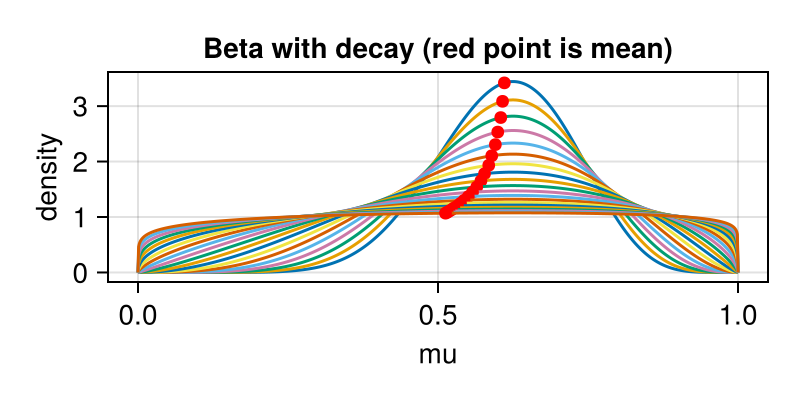

In [3]:
x = range(0, 1, length=1000)
a = 10
b = 6
decay = 0.2
f = Figure(size = (400, 200))
ax = Axis(f[1, 1], xlabel = "mu", ylabel = "density", title="Beta with decay (red point is mean)")
for i in 1:20
    p = pdf(Beta(a+1,b+1), x)
    lines!(ax, x, p)
    # Plot mean of dist
    m = (a+1)/(a+b+2)
    # Find closest point to m in X
    ind = Int(round(m * 1000))
    scatter!(ax, x[ind], p[ind], color = :red)
    a = a * (1 - decay)
    b = b * (1 - decay)
end
f

## Alternative Formulations

Note that the beta bernoulli model can be directly framed in terms of $\mu$ and $\sigma^2$. We can derive update rules for both of them rather than $\alpha$ and $\beta$, but these rules are somewhat more complicated and so are not used below.

# Likelihood

In [4]:
function em_opt_extended(trials,subs,X,betas,sigma,lik_fn,varnames;
    emtol=1e-3, maxiter=100, full=true, extended=true, quiet=false, threads=true, nstarts=1, noprior=false, startx=nothing)
    if noprior
        if nstarts > 1
            return emnoprior(trials,subs,X,betas,sigma,lik_fn;nstarts=nstarts)
        else
            return emnoprior(trials,subs,X,betas,sigma,lik_fn;nstarts=1)
        end
    else
        _startx = []
        if nstarts > 1
            _startx = eminits(trials,subs,X,betas,sigma,lik_fn;nstarts=nstarts,threads=threads)
        elseif !isnothing(startx)
            _startx = startx
        end
        (betas,sigma,x,l,h,opt_rec) = em(trials,subs,X,betas,sigma,lik_fn; emtol=emtol, full=full, maxiter=maxiter, quiet=quiet, threads=threads, startx=_startx);
        if extended
            try
                @info "Running emerrors"
                (standarderrors,pvalues,covmtx) = emerrors(trials,subs,x,X,h,betas,sigma,lik_fn)
                return EMResultsExtended(varnames,betas,sigma,x,l,h,opt_rec,standarderrors,pvalues,covmtx)
            catch err
                if isa(err, SingularException) || isa(err, DomainError) || isa(err, LAPACKException)
                @warn err
                    @warn "emerrors failed to run. Re-check fitting. Returning EMResults"
                    return EMResults(varnames,betas,sigma,x,l,h,opt_rec)
                else
                    rethrow()
                end
            end
        else
            return EMResults(varnames,betas,sigma,x,l,h,opt_rec)
        end
    end
end

function beta_mu(α, β)
    return α / (α + β)
end

function beta_var(α, β)
    return α * β / ((α + β)^2 * (α + β + 1))
end

function beta_lik(data, βgo, βstay::V, βleaf, stay_bias::W, turn_bias, spatial_bias, leaf_turn_bias, leaf_spatial_bias, beta_decay, γ2, retain_belief, delay_turn_bias::Bool, rewscaled::Bool, add_leaf::Bool, record::Bool) where {V, W}
    U = promote_type(eltype(βstay), eltype(stay_bias))  # this is a bit of a hack so that we can optionally have either of these fixed at 0
    # mode = "likelihood"

    # rename the variables for easy acccess
    r = data.reward
    c1 = data.stemchoice
    c2 = data.leafchoice

    # initialize 
    lik = 0.
    lik_go = 0.
    lik_stay = 0.
    lp_stay = 0.
    lp_turn = 0.
    lp_go = 0.
    prevs::Int = 0 #stem
    prevl::Int = 0 #leaf
    stem_stay_p = zeros(U, length(c1))
    stem_turn_alone_p = zeros(U, length(c1))
    stem_go_turn_p = zeros(U, length(c1))
    stem_1_p = zeros(U, length(c1))
    stem_2_p = zeros(U, length(c1))
    stem_3_p = zeros(U, length(c1))
    leaf_1_p = zeros(U, length(c1))
    leaf_2_p = zeros(U, length(c1))

    # Beta dist variables
    betadist_α = zeros(U, 3, 2, length(c1)+1)
    betadist_β = zeros(U, 3, 2, length(c1)+1)
    betadist_α[:, :, 1] .= 1.0
    betadist_β[:, :, 1] .= 1.0

    # Q-values
    # Choice-level representation
    Q = zeros(U,3,2,length(c1)+1)
    Qstem = zeros(U,3,length(c1))
    Qleaf = zeros(U,2,length(c1))
    Q[:, :, 1] .= betadist_α[:, :, 1] ./ (betadist_α[:, :, 1] + betadist_β[:, :, 1])
    if rewscaled
        @views Q[:, :, 1] .-= 0.5
    end

    for i in eachindex(c1)
        if ((i>1) && (data.daysessionnum[i] != data.daysessionnum[i-1]))
            betadist_α[:, :, 1] .= 1.0
            betadist_β[:, :, 1] .= 1.0
            @views Q[:, :, i] .= betadist_α[:, :, i] ./ (betadist_α[:, :, i] + betadist_β[:, :, i])
            if rewscaled
                @views Q[:, :, i] .-= 0.5
            end
            prevs = 0
            prevl = 0
        end

        # this is the (scaled) value of switching to each alternative stem
        # mean averages over both leaves
        # 
        # Seems to be faster breaking it up into the three calculations
        @views Qstem[1, i] = mean(Q[1, :, i]) * βgo
        @views Qstem[2, i] = mean(Q[2, :, i]) * βgo
        @views Qstem[3, i] = mean(Q[3, :, i]) * βgo

        if prevs > 0
            # this is the (scaled) value of staying with the current stem
            # uses only the value of the next leaf
            # plus the bias toward staying
            Qstem[prevs, i] = βstay * ((1.0 - γ2) * Q[prevs,3-prevl,i] + γ2 * Q[prevs,prevl,i]) + stay_bias
            # @views Qstem[:, i] .*= βgo
            # spatial bias
            # 1 -> 2, 2->3, 3->1
            # Probability of stay/switch
            # mod1(prevs + 1, 3) and mod1(prevs + 2, 3) give us the other two stems
            # log(exp(Q_x) / sum(exp.(Q))) -> Q_x - logsumexp(Q)
            if delay_turn_bias  # Compute stay/go before we add a turn bias
                @views lp_stay = Qstem[prevs, i] - logsumexp(Qstem[:, i])
                @views lp_go = logsumexp(Qstem[[mod1(prevs + 1, 3), mod1(prevs + 2, 3)], i]) - logsumexp(Qstem[:, i])
                Qstem[mod1(prevs + 1, 3), i] += spatial_bias[prevs] + turn_bias
            else # Or after we add the turn bias
                Qstem[mod1(prevs + 1, 3), i] += spatial_bias[prevs] + turn_bias
                @views lp_stay = Qstem[prevs, i] - logsumexp(Qstem[:, i])
                @views lp_go = logsumexp(Qstem[[mod1(prevs + 1, 3), mod1(prevs + 2, 3)], i]) - logsumexp(Qstem[:, i])
            end
            if prevs == c1[i]  # If a stay trial, just the stay/go likelihood
                ll = lp_stay
            else  # If a go trial, p(go) times the left/right turn choice
                @views lp_turn = Qstem[c1[i], i] - logsumexp(Qstem[[mod1(prevs + 1, 3), mod1(prevs + 2, 3)], i])
                ll = lp_go + lp_turn
            end
            stem_stay_p[i] = exp(lp_stay)
            stem_turn_alone_p[i] = exp(lp_turn)
            stem_go_turn_p[i] = exp(lp_go + lp_turn)

            @views stem_1_p[i] = exp(Qstem[1, i] - logsumexp(Qstem[:, i]))
            @views stem_2_p[i] = exp(Qstem[2, i] - logsumexp(Qstem[:, i]))
            @views stem_3_p[i] = exp(Qstem[3, i] - logsumexp(Qstem[:, i]))
        else  # First trial, no biases and just three-way choice
            # @views Qstem[:, i] .*= βgo
            @views ll = Qstem[c1[i], i] - logsumexp(Qstem[:, i])
        end

        # log likelihood of stem choice (log of logistic)
        lik += ll
        if ((i>1) && c1[i] != prevs)
            lik_go += ll
        else
            lik_stay += ll
        end

        ## Leaf
        if ((prevs != c1[i]) && add_leaf)
            @views Qleaf[:, i] .= Q[c1[i], :, i]
            @views Qleaf[:, i] .*= βleaf
            # Add leaf bias
            Qleaf[1, i] += leaf_turn_bias + leaf_spatial_bias[c1[i]]
            # log likelihood of leaf choice on switches only
            @views lik += Qleaf[c2[i], i] - logsumexp(Qleaf[ :, i]);

            @views leaf_1_p[i] = Qleaf[1, i] - logsumexp(Qleaf[:, i]);
            @views leaf_2_p[i] = Qleaf[2, i] - logsumexp(Qleaf[:, i]);
        end

        # learn about the chosen leaf
        betadist_α[:, :, i+1] .= (betadist_α[:, :, i] .- 1) .* (1.0 - beta_decay * 0.5) .+ 1
        betadist_β[:, :, i+1] .= (betadist_β[:, :, i] .- 1) .* (1.0 - beta_decay * 0.5) .+ 1
        # betadist_α[:, :, i+1] .= betadist_α[:, :, i] .* (1.0 - beta_decay * 0.5)
        # betadist_β[:, :, i+1] .= betadist_β[:, :, i] .* (1.0 - beta_decay * 0.5)
        if r[i] == 1.0
            betadist_α[c1[i], c2[i], i+1] += 1
        else
            betadist_β[c1[i], c2[i], i+1] += 1
        end

        # Update estimated reward probabilities
        @views Q[:, :, i+1] .= betadist_α[:, :, i+1] ./ (betadist_α[:, :, i+1] .+ betadist_β[:, :, i+1])
        if rewscaled
            @views Q[:, :, i+1] .-= 0.5
        end

        prevs = c1[i]
        prevl = c2[i]
    end
    
    if record
        betadist_var = beta_var.(betadist_α, betadist_β)
        betadist_mu = beta_mu.(betadist_α, betadist_β)
        record_df = DataFrame(
            # means
            betadist_α1 = betadist_α[1, 1, 1:length(c1)],
            betadist_α2 = betadist_α[1, 2, 1:length(c1)],
            betadist_α3 = betadist_α[2, 1, 1:length(c1)],
            betadist_α4 = betadist_α[2, 2, 1:length(c1)],
            betadist_α5 = betadist_α[3, 1, 1:length(c1)],
            betadist_α6 = betadist_α[3, 2, 1:length(c1)],
            betadist_β1 = betadist_β[1, 1, 1:length(c1)],
            betadist_β2 = betadist_β[1, 2, 1:length(c1)],
            betadist_β3 = betadist_β[2, 1, 1:length(c1)],
            betadist_β4 = betadist_β[2, 2, 1:length(c1)],
            betadist_β5 = betadist_β[3, 1, 1:length(c1)],
            betadist_β6 = betadist_β[3, 2, 1:length(c1)],
            betadist_mu1 = betadist_mu[1, 1, 1:length(c1)],
            betadist_mu2 = betadist_mu[1, 2, 1:length(c1)],
            betadist_mu3 = betadist_mu[2, 1, 1:length(c1)],
            betadist_mu4 = betadist_mu[2, 2, 1:length(c1)],
            betadist_mu5 = betadist_mu[3, 1, 1:length(c1)],
            betadist_mu6 = betadist_mu[3, 2, 1:length(c1)],
            betadist_var1 = betadist_var[1, 1, 1:length(c1)],
            betadist_var2 = betadist_var[1, 2, 1:length(c1)],
            betadist_var3 = betadist_var[2, 1, 1:length(c1)],
            betadist_var4 = betadist_var[2, 2, 1:length(c1)],
            betadist_var5 = betadist_var[3, 1, 1:length(c1)],
            betadist_var6 = betadist_var[3, 2, 1:length(c1)],
            # variances
            # Base Q values
            Q1 = Q[1, 1, 1:length(c1)],
            Q2 = Q[1, 2, 1:length(c1)],
            Q3 = Q[2, 1, 1:length(c1)],
            Q4 = Q[2, 2, 1:length(c1)],
            Q5 = Q[3, 1, 1:length(c1)],
            Q6 = Q[3, 2, 1:length(c1)],
            Qstem1 = Qstem[1, :],
            Qstem2 = Qstem[2, :],
            Qstem3 = Qstem[3, :],
            Qleaf1 = Qleaf[1, :],
            Qleaf2 = Qleaf[2, :],
            stem_stay_p = stem_stay_p,
            stem_turn_alone_p = stem_turn_alone_p,
            stem_go_turn_p = stem_go_turn_p,
            stem_1_p = stem_1_p,
            stem_2_p = stem_2_p,
            stem_3_p = stem_3_p,
            leaf_1_p = leaf_1_p,
            leaf_2_p = leaf_2_p,
        )
        record_df[!, :stem_choice_p] .= 0.0
        record_df[!, :leaf_choice_p] .= 0.0
        record_df[!, :prev_global_variance] .= (
            record_df.betadist_var1 .+ record_df.betadist_var2 .+ 
            record_df.betadist_var3 .+ record_df.betadist_var4 .+ 
            record_df.betadist_var5 .+ record_df.betadist_var6)
        record_df[!, :prev_leaf_variance] .= 0.0
        record_df[!, :upcoming_leaf_variance] .= 0.0
        record_df[!, :next_choice_variance] .= 0.0
        record_df[!, :prev_local_variance] .= 0.0
        record_df[!, :next_choice_local_variance] .= 0.0
        record_df[!, :next_choice_local_variance_gamma] .= 0.0

        for i in 1:6
            record_df[!, Symbol("betadist_mu$(i)_delta")] .= 0.0
            record_df[!, Symbol("betadist_var$(i)_delta")] .= 0.0
            record_df[!, Symbol("betadist_var$(i)_ratio")] .= 0.0
            record_df[2:end, Symbol("betadist_mu$(i)_delta")] .= record_df[2:end, Symbol("betadist_mu$(i)")] .- record_df[1:end-1, Symbol("betadist_mu$(i)")]
            record_df[2:end, Symbol("betadist_var$(i)_delta")] .= record_df[2:end, Symbol("betadist_var$(i)")] .- record_df[1:end-1, Symbol("betadist_var$(i)")]
            record_df[2:end, Symbol("betadist_var$(i)_ratio")] .= record_df[2:end, Symbol("betadist_var$(i)")] ./ record_df[1:end-1, Symbol("betadist_var$(i)")]
        end
        record_df[!, :prev_leaf_mu_delta] .= 0.0
        record_df[!, :prev_leaf_var_delta] .= 0.0
        record_df[!, :prev_leaf_var_ratio] .= 0.0
        record_df[!, :next_choice_leaf_mu_delta] .= 0.0
        record_df[!, :next_choice_leaf_var_delta] .= 0.0
        record_df[!, :next_choice_leaf_var_ratio] .= 0.0
        record_df[!, :upcoming_leaf_mu_delta] .= 0.0
        record_df[!, :upcoming_leaf_var_delta] .= 0.0
        record_df[!, :upcoming_leaf_var_ratio] .= 0.0
        record_df[!, :prev_global_mu_delta] .= (
            record_df.betadist_mu1_delta .+ record_df.betadist_mu2_delta .+
            record_df.betadist_mu3_delta .+ record_df.betadist_mu4_delta .+
            record_df.betadist_mu5_delta .+ record_df.betadist_mu6_delta
        )
        record_df[!, :prev_global_mu_delta_abs] .= (
            abs.(record_df.betadist_mu1_delta) .+ abs.(record_df.betadist_mu2_delta) .+
            abs.(record_df.betadist_mu3_delta) .+ abs.(record_df.betadist_mu4_delta) .+
            abs.(record_df.betadist_mu5_delta) .+ abs.(record_df.betadist_mu6_delta)
        )
        record_df[!, :prev_global_var_delta] .= (
            record_df.betadist_var1_delta .+ record_df.betadist_var2_delta .+
            record_df.betadist_var3_delta .+ record_df.betadist_var4_delta .+
            record_df.betadist_var5_delta .+ record_df.betadist_var6_delta
        )
        record_df[!, :prev_global_var_delta_abs] .= (
            abs.(record_df.betadist_var1_delta) .+ abs.(record_df.betadist_var2_delta) .+
            abs.(record_df.betadist_var3_delta) .+ abs.(record_df.betadist_var4_delta) .+
            abs.(record_df.betadist_var5_delta) .+ abs.(record_df.betadist_var6_delta)
        )

        # Label trials with probability of eventual choice
        for i in 1:nrow(record_df)
            s = c1[i]
            record_df[i, :stem_choice_p] = record_df[i, Symbol("stem_$(s)_p")]
            l = c2[i]
            record_df[i, :leaf_choice_p] = record_df[i, Symbol("leaf_$(l)_p")]
            prevleaf = (c1[i]-1)*2 + c2[i]
            upcomingleaf = (c1[i]-1)*2 + 3-c2[i]
            record_df[i, :prev_leaf_variance] = record_df[i, Symbol("betadist_var$(prevleaf)")]
            record_df[i, :prev_leaf_mu_delta] = record_df[i, Symbol("betadist_mu$(prevleaf)_delta")]
            record_df[i, :prev_leaf_var_delta] = record_df[i, Symbol("betadist_var$(prevleaf)_delta")]
            record_df[i, :prev_leaf_var_ratio] = record_df[i, Symbol("betadist_var$(prevleaf)_ratio")]
            if i < length(c1)
                nextleaf = (c1[i+1]-1)*2 + c2[i+1]
                record_df[i, :next_choice_variance] = record_df[i+1, Symbol("betadist_var$(nextleaf)")]
                record_df[i, :next_choice_leaf_mu_delta] = record_df[i+1, Symbol("betadist_mu$(nextleaf)_delta")]
                record_df[i, :next_choice_leaf_var_delta] = record_df[i+1, Symbol("betadist_var$(nextleaf)_delta")]
                record_df[i, :next_choice_leaf_var_ratio] = record_df[i+1, Symbol("betadist_var$(nextleaf)_ratio")]
                @views record_df[i, :next_choice_local_variance] = sum(betadist_var[c1[i+1], :, i+1])
                @views record_df[i, :next_choice_local_variance_gamma] = (1 - γ2) * betadist_var[c1[i+1], c2[i+1], i+1] + γ2 * betadist_var[c1[i+1], 3-c2[i+1], i+1]
                record_df[i, :upcoming_leaf_variance] = record_df[i+1, Symbol("betadist_var$(upcomingleaf)")]
                record_df[i, :upcoming_leaf_mu_delta] = record_df[i+1, Symbol("betadist_mu$(upcomingleaf)_delta")]
                record_df[i, :upcoming_leaf_var_delta] = record_df[i+1, Symbol("betadist_var$(upcomingleaf)_delta")]
                record_df[i, :upcoming_leaf_var_ratio] = record_df[i+1, Symbol("betadist_var$(upcomingleaf)_ratio")]
            end
            @views record_df[i, :prev_local_variance] = sum(betadist_var[c1[i], :, i+1])
        end
        return -lik, record_df
    else
        return -lik
    end
    # elseif mode=="lik_stay_go"
    #     return [-lik_go,-lik_stay] 
    # elseif mode=="sim"
    #     return Q[:,:,1:length(c1)]
    # elseif mode=="sim_effective"
    #     return Qeff[:,:,1:length(c1)]
    # end
end

function beta_lik(data; βgo=0.0, βstay=0.0, βleaf=0.0, stay_bias=0.0, turn_bias=0.0, spatial_bias=[0.0, 0.0, 0.0], leaf_turn_bias=0.0, leaf_spatial_bias=[0.0, 0.0, 0.0], beta_decay=0.0, γ2=0.0, retain_belief=0.0, delay_turn_bias=false, rewscaled=false, add_leaf=true, record=false)
    beta_lik(data, βgo, βstay, βleaf, stay_bias, turn_bias, spatial_bias, leaf_turn_bias, leaf_spatial_bias, beta_decay, γ2, retain_belief, delay_turn_bias, rewscaled, add_leaf, record)
end

"""
VKF likelihood function using parameters from an existing EM run

Can pass in extra parameters with `params`: these will override the EM results

Note that params should be a dictionary of symbols to values, e.g. (:βgo => 2.0)

If `subject` is provided, use parameters from subject `subject`.
Otherwise use group-level betas
"""
function beta_lik(data, results::T; subject=0, params=nothing, delay_turn_bias=false, rewscaled=false, add_leaf=true, record=false) where T <: EMResultsAbstract
    d = Dict{Symbol, Any}()
    # The trick here is that we can pass in a dictionary of (symbol => value) as kwargs
    # Then everything not present the EMResults struct is left at its default value
    if subject == 0
        for i in eachindex(results.varnames)
            d[Symbol(results.varnames[i])] = results.betas[i]
        end
    else
        for i in eachindex(results.varnames)
            d[Symbol(results.varnames[i])] = results.x[subject, i]
        end
    end
    if haskey(d, :beta_decay)
        d[:beta_decay] = unitnorm(d[:beta_decay])
    end
    if haskey(d, :γ2)
        d[:γ2] = unitnorm(d[:γ2])
    end
    if haskey(d, :retain_belief)
        d[:retain_belief] = unitnorm(d[:retain_belief])
    end
    # Combine array parameters
    if haskey(d, :spatial_1)
        d[:spatial_bias] = [d[:spatial_1], d[:spatial_2], d[:spatial_3]]
        delete!(d, :spatial_1)
        delete!(d, :spatial_2)
        delete!(d, :spatial_3)
    end
    if haskey(d, :leaf_spatial_1)
        d[:leaf_spatial_bias] = [d[:leaf_spatial_1], d[:leaf_spatial_2], d[:leaf_spatial_3]]
        delete!(d, :leaf_spatial_1)
        delete!(d, :leaf_spatial_2)
        delete!(d, :leaf_spatial_3)
    end
    # Incorporate any extra parameters
    if !isnothing(params)
        for (k, v) in params
            d[k] = v
        end
    end
    beta_lik(data; delay_turn_bias, rewscaled, add_leaf, record, d...)
end


function run_beta_lik(df; maxiter=100, emtol=1e-3, full=true, extended=false, quiet=false, threads=true, nstarts=1,
    add_βgo=true,
    add_βstay=true,
    add_βleaf=false,
    add_stay_bias=false,
    add_turn_bias=false,
    add_spatial_bias=false,
    add_leaf_turn_bias=false,
    add_leaf_spatial_bias=false,
    add_beta_decay=false,
    add_γ2=false,
    add_retain_belief=false,
    delay_turn_bias=false,
    rewscaled=false,
    add_leaf=true,
    subjlevel=:daynum,
    )

    @show add_βgo
    @show add_βstay
    @show add_βleaf
    @show add_stay_bias
    @show add_turn_bias
    @show add_spatial_bias
    @show add_leaf_turn_bias
    @show add_leaf_spatial_bias
    @show add_beta_decay
    @show add_γ2
    @show delay_turn_bias
    @show rewscaled
    @show add_leaf
    @show subjlevel

    data = copy(df)
    data[:, :sub] = data[:, subjlevel]
    subs = unique(data[:,:sub]) #in this case subs is just differentiating days rather than rats/subjects
    NS = length(subs) #number of subjects/days
    X = ones(NS) # (group level design matrix); #x group level design matrix...

    initbetas = Matrix{Float64}(undef, 1, 0)
    initsigma = Vector{Float64}(undef, 0)
    varnames = Vector{String}(undef, 0)

    if add_βgo
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 5)
        push!(varnames, "βgo")
    end
    if add_βstay
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 5)
        push!(varnames, "βstay")
    end
    if add_βleaf
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 5)
        push!(varnames, "βleaf")
    end
    if add_stay_bias
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 5)
        push!(varnames, "stay_bias")
    end
    if add_turn_bias
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 1)
        push!(varnames, "turn_bias")
    end
    if add_spatial_bias
        initbetas = hcat(initbetas, 0, 0, 0)
        initsigma = vcat(initsigma, 1, 1, 1)
        varnames = vcat(varnames, "spatial_1", "spatial_2", "spatial_3")
    end
    if add_leaf_turn_bias
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 1)
        push!(varnames, "leaf_turn_bias")
    end
    if add_leaf_spatial_bias
        initbetas = hcat(initbetas, 0, 0, 0)
        initsigma = vcat(initsigma, 1, 1, 1)
        varnames = vcat(varnames, "leaf_spatial_1", "leaf_spatial_2", "leaf_spatial_3")
    end
    if add_beta_decay
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 1)
        push!(varnames, "beta_decay")
    end
    if add_γ2
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 1)
        push!(varnames, "γ2")
    end
    if add_retain_belief
        initbetas = hcat(initbetas, 0)
        push!(initsigma, 1)
        push!(varnames, "retain_belief")
    end

    @show varnames

    function fn(params, data)
        i = 1

        if add_βgo
            βgo = params[i] # beta for go choice
            i += 1
        else
            βgo = 0.0
        end

        if add_βstay
            βstay = params[i] # beta for stay choice
            i += 1
        else
            βstay = 0.0
        end

        if add_βleaf
            βleaf = params[i] # beta for leaf choice on switch
            i += 1
        else
            βleaf = 0.0
        end

        if add_stay_bias
            stay_bias = params[i] # beta for leaf choice on switch
            i += 1
        else
            stay_bias = 0.0
        end

        if add_turn_bias
            turn_bias = params[i] # beta for leaf choice on switch
            i += 1
        else
            turn_bias = 0.0
        end

        if add_spatial_bias
            spatial_bias = params[i:i+2] # beta for leaf choice on switch
            i += 3
        else
            spatial_bias = [0.0, 0.0, 0.0]
        end

        if add_leaf_turn_bias
            leaf_turn_bias = params[i] # beta for leaf choice on switch
            i += 1
        else
            leaf_turn_bias = 0.0
        end

        if add_leaf_spatial_bias
            leaf_spatial_bias = params[i:i+2] # beta for leaf choice on switch
            i += 3
        else
            leaf_spatial_bias = [0.0, 0.0, 0.0]
        end

        if add_beta_decay
            beta_decay = unitnorm(params[i])
            i += 1
        else
            beta_decay = 0.0
        end

        if add_γ2
            γ2 = unitnorm(params[i])
            i += 1
        else
            γ2 = 0.0
        end

        if add_retain_belief
            retain_belief = unitnorm(params[i])
            i += 1
        else
            retain_belief = 0.0
        end

        i += 1

        return beta_lik(data, βgo, βstay, βleaf, stay_bias, turn_bias, spatial_bias, leaf_turn_bias, leaf_spatial_bias, beta_decay, γ2, retain_belief, delay_turn_bias, rewscaled, add_leaf, false)
    end

    em_opt_extended(data,subs,X,initbetas,initsigma,fn,varnames; emtol, maxiter, full, extended, quiet, threads, nstarts, startx=nothing)
end

function find_Q_vals_beta_lik(df, results; add_leaf, delay_turn_bias, rewscaled, params=nothing, subjlevel=:daynum)
    data = copy(df)
    data[:, :sub] = data[:, subjlevel]
    nsubjs = maximum(data.sub)
    liks = zeros(nsubjs)
    dfs = []
    for i in 1:nsubjs
        (liks[i], df) = beta_lik(view(data, data.sub .== i, :), results;
        subject=i, add_leaf, delay_turn_bias, rewscaled, params, record=true)
        push!(dfs, df)
    end
    record_df = vcat(dfs...) # Combine all session results
    hcat(data, record_df) # Append columns to the original data
end

find_Q_vals_beta_lik (generic function with 1 method)

# Model Fits

Running each of the animals below

In [5]:
animal_ind = 1
animal = animals[animal_ind]
data = load_animal(animal, "..")
r_beta_1 = run_beta_lik(data; maxiter=100, emtol=1e-3, full=false, extended=true, quiet=true, threads=true, nstarts=10,
    add_βgo=true,
    add_βstay=true,
    add_βleaf=false,
    add_stay_bias=true,
    add_turn_bias=true,
    add_spatial_bias=false,
    add_leaf_turn_bias=false,
    add_leaf_spatial_bias=false,
    add_beta_decay=true,
    add_γ2=true,
    add_retain_belief=false,
    delay_turn_bias=false,
    rewscaled=false,
    add_leaf=false,
    subjlevel=:daynum,
    )

add_βgo = true
add_βstay = true
add_βleaf = false
add_stay_bias = true
add_turn_bias = true
add_spatial_bias = false
add_leaf_turn_bias = false
add_leaf_spatial_bias = false
add_beta_decay = true
add_γ2 = true
delay_turn_bias = false
rewscaled = false
add_leaf = false
subjlevel = :daynum
varnames = ["βgo", "βstay", "stay_bias", "turn_bias", "beta_decay", "γ2"]


┌ Info: Running emerrors
└ @ Main /Users/arik/Library/CloudStorage/Dropbox/Princeton/Loren Frank Lab/SpatialBanditTask/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:19


EMResultsExtended(["βgo", "βstay", "stay_bias", "turn_bias", "beta_decay", "γ2"], [4.574814356663914 13.47310776235305 … -0.21024551704278457 -0.5138742002980747], [0.08086320388586007 0.0 … 0.0 0.0; 0.0 0.02638934541414003 … 0.0 0.0; … ; 0.0 0.0 … 0.19341217998581753 0.0; 0.0 0.0 … 0.0 0.02075046031902817], [4.5973154725541345 13.424550510763355 … 0.11119970504309762 -0.43758511030638675; 4.314616492053967 13.506417728291096 … -1.275230991178747 -0.6030942741670603; … ; 4.782330648506617 13.408675500382875 … -0.03942351810465415 -0.5259916305988821; 4.640137032378943 13.471434478192952 … -0.10779516404921528 -0.452715343492548], [258.5504672563483, 231.00803254145015, 323.1540653573329, 272.54028962028036, 364.808322949199, 256.9887020865781, 229.99333071039672, 254.29832658192572, 183.20548762533952, 310.307804030475, 189.26564450676466], [0.06737290425403022 0.003786011178512697 … 0.002548510392592759 9.835845465467633e-5; 0.003786011178512699 0.025330734616985782 … 0.00166198856529

In [6]:
animal_ind = 2
animal = animals[animal_ind]
data = load_animal(animal, "..")
r_beta_2 = run_beta_lik(data; maxiter=100, emtol=1e-3, full=false, extended=true, quiet=true, threads=true, nstarts=10,
    add_βgo=true,
    add_βstay=true,
    add_βleaf=false,
    add_stay_bias=true,
    add_turn_bias=true,
    add_spatial_bias=false,
    add_leaf_turn_bias=false,
    add_leaf_spatial_bias=false,
    add_beta_decay=true,
    add_γ2=true,
    add_retain_belief=false,
    delay_turn_bias=false,
    rewscaled=false,
    add_leaf=false,
    subjlevel=:daynum,
    )

add_βgo = true
add_βstay = true
add_βleaf = false
add_stay_bias = true
add_turn_bias = true
add_spatial_bias = false
add_leaf_turn_bias = false
add_leaf_spatial_bias = false
add_beta_decay = true
add_γ2 = true
delay_turn_bias = false
rewscaled = false
add_leaf = false
subjlevel = :daynum
varnames = ["βgo", "βstay", "stay_bias", "turn_bias", "beta_decay", "γ2"]


┌ Info: Running emerrors
└ @ Main /Users/arik/Library/CloudStorage/Dropbox/Princeton/Loren Frank Lab/SpatialBanditTask/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:19


EMResultsExtended(["βgo", "βstay", "stay_bias", "turn_bias", "beta_decay", "γ2"], [4.468438720933815 9.659890671534587 … -0.9686468138861577 -0.5051743491492675], [0.9877862983525698 0.0 … 0.0 0.0; 0.0 0.03878118475734997 … 0.0 0.0; … ; 0.0 0.0 … 0.8464592997970097 0.0; 0.0 0.0 … 0.0 0.015343178175892577], [5.513453821302536 9.638253894065157 … -1.4282203779220162 -0.4658960744344873; 5.751505299117955 9.636950307888538 … -0.4191955429862328 -0.5749979236506364; … ; 3.207941003463572 9.67512013717954 … 0.45073831217787774 -0.5240559850774134; 3.9025212626090133 9.652783484703455 … 0.0333415552667051 -0.5078096958005872], [121.023934784267, 146.0368062112929, 65.58197537937939, 58.67791522597724, 147.35745407404846, 94.80904962158786, 114.37225310629908, 127.12547381229973, 109.29421975902709, 144.72807559075778, 120.20768092655973, 112.5864736710957, 115.2195858895103, 75.07026585859047, 100.43364629171795, 99.62028088338386], [0.3686851860797348 0.0230286444610998 … -0.020729925916103

In [7]:
animal_ind = 3
animal = animals[animal_ind]
data = load_animal(animal, "..")
r_beta_3 = run_beta_lik(data; maxiter=100, emtol=1e-3, full=false, extended=true, quiet=true, threads=true, nstarts=10,
    add_βgo=true,
    add_βstay=true,
    add_βleaf=false,
    add_stay_bias=true,
    add_turn_bias=true,
    add_spatial_bias=false,
    add_leaf_turn_bias=false,
    add_leaf_spatial_bias=false,
    add_beta_decay=true,
    add_γ2=true,
    add_retain_belief=false,
    delay_turn_bias=false,
    rewscaled=false,
    add_leaf=false,
    subjlevel=:daynum,
    )

add_βgo = true
add_βstay = true
add_βleaf = false
add_stay_bias = true
add_turn_bias = true
add_spatial_bias = false
add_leaf_turn_bias = false
add_leaf_spatial_bias = false
add_beta_decay = true
add_γ2 = true
delay_turn_bias = false
rewscaled = false
add_leaf = false
subjlevel = :daynum
varnames = ["βgo", "βstay", "stay_bias", "turn_bias", "beta_decay", "γ2"]


┌ Info: Running emerrors
└ @ Main /Users/arik/Library/CloudStorage/Dropbox/Princeton/Loren Frank Lab/SpatialBanditTask/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:19


EMResultsExtended(["βgo", "βstay", "stay_bias", "turn_bias", "beta_decay", "γ2"], [5.631691735603592 14.808124093522528 … -0.2633949877487873 -0.5361278135908948], [0.10701974451074858 0.0 … 0.0 0.0; 0.0 3.001647143096514 … 0.0 0.0; … ; 0.0 0.0 … 0.023724285464037185 0.0; 0.0 0.0 … 0.0 0.0005970978642537586], [5.7142398880083505 11.465869530165268 … -0.37174491384086517 -0.5386442533795827; 5.578194974546663 13.432077932135678 … -0.3296792773187356 -0.5398963802054203; … ; 5.650698729205183 15.699293403578517 … -0.23767597994905468 -0.5356059137222818; 5.634601311035519 16.159660213876073 … -0.1762355749526255 -0.5287366166887081], [320.93405781575785, 328.7546570647882, 295.7627905287028, 250.7650830060458, 220.35941236801366, 169.80024774470294, 215.75988858551025, 242.8897772142312], [0.0982157756966168 0.07012064018943634 … 0.002975855495209057 2.070847222525814e-5; 0.07012064018943623 0.4569573198275543 … 0.014003887938742982 -0.0001191727162350049; … ; 0.0029758554952090586 0.014

In [8]:
animal_ind = 4
animal = animals[animal_ind]
data = load_animal(animal, "..")
r_beta_4 = run_beta_lik(data; maxiter=100, emtol=1e-3, full=false, extended=true, quiet=true, threads=true, nstarts=10,
    add_βgo=true,
    add_βstay=true,
    add_βleaf=false,
    add_stay_bias=true,
    add_turn_bias=true,
    add_spatial_bias=false,
    add_leaf_turn_bias=false,
    add_leaf_spatial_bias=false,
    add_beta_decay=true,
    add_γ2=true,
    add_retain_belief=false,
    delay_turn_bias=false,
    rewscaled=false,
    add_leaf=false,
    subjlevel=:daynum,
    )

add_βgo = true
add_βstay = true
add_βleaf = false
add_stay_bias = true
add_turn_bias = true
add_spatial_bias = false
add_leaf_turn_bias = false
add_leaf_spatial_bias = false
add_beta_decay = true
add_γ2 = true
delay_turn_bias = false
rewscaled = false
add_leaf = false
subjlevel = :daynum
varnames = ["βgo", "βstay", "stay_bias", "turn_bias", "beta_decay", "γ2"]


┌ Info: Running emerrors
└ @ Main /Users/arik/Library/CloudStorage/Dropbox/Princeton/Loren Frank Lab/SpatialBanditTask/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:19


EMResultsExtended(["βgo", "βstay", "stay_bias", "turn_bias", "beta_decay", "γ2"], [6.200903909588425 15.123027851284668 … 0.21997852000068194 -0.6709595272823279], [0.12423724607431612 0.0 … 0.0 0.0; 0.0 5.139341771345432 … 0.0 0.0; … ; 0.0 0.0 … 0.20260577396272308 0.0; 0.0 0.0 … 0.0 0.018469090956986664], [6.109162629372963 10.817449531547528 … 0.9068597102624311 -0.679318831804683; 6.127918917856656 13.506995671024958 … 0.3367574758263531 -0.748588413592844; … ; 6.235048513157779 17.01109338419064 … 0.08445437752903853 -0.6597104360036166; 6.264497732225329 17.37412353997716 … 0.014564532524908958 -0.4811378918808444], [345.49430225755987, 460.5802928880505, 449.66600939167915, 416.92316431385825, 364.56354835568783, 365.8433978544076, 276.83187571001054, 369.72587692611563], [0.1210073367424534 0.059270818509545714 … 0.009791233818398694 4.5909859108154276e-5; 0.05927081850954582 1.0441001238941607 … 0.09847690584057955 0.0006471955559069518; … ; 0.009791233818398713 0.098476905840

In [9]:
animal_ind = 5
animal = animals[animal_ind]
data = load_animal(animal, "..")
r_beta_5 = run_beta_lik(data; maxiter=100, emtol=1e-3, full=false, extended=true, quiet=true, threads=true, nstarts=10,
    add_βgo=true,
    add_βstay=true,
    add_βleaf=false,
    add_stay_bias=true,
    add_turn_bias=true,
    add_spatial_bias=false,
    add_leaf_turn_bias=false,
    add_leaf_spatial_bias=false,
    add_beta_decay=true,
    add_γ2=true,
    add_retain_belief=false,
    delay_turn_bias=false,
    rewscaled=false,
    add_leaf=false,
    subjlevel=:daynum,
    )

add_βgo = true
add_βstay = true
add_βleaf = false
add_stay_bias = true
add_turn_bias = true
add_spatial_bias = false
add_leaf_turn_bias = false
add_leaf_spatial_bias = false
add_beta_decay = true
add_γ2 = true
delay_turn_bias = false
rewscaled = false
add_leaf = false
subjlevel = :daynum
varnames = ["βgo", "βstay", "stay_bias", "turn_bias", "beta_decay", "γ2"]


┌ Info: Running emerrors
└ @ Main /Users/arik/Library/CloudStorage/Dropbox/Princeton/Loren Frank Lab/SpatialBanditTask/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:19


EMResultsExtended(["βgo", "βstay", "stay_bias", "turn_bias", "beta_decay", "γ2"], [6.244436619891816 14.260310552722071 … -0.16500494722871467 -0.5802979486560599], [3.1851337106694073 0.0 … 0.0 0.0; 0.0 6.17859596437245 … 0.0 0.0; … ; 0.0 0.0 … 0.005627968330961616 0.0; 0.0 0.0 … 0.0 0.015873769074455705], [4.048587040558987 11.04041522323994 … -0.20082418227961793 -0.758450551475985; 5.526636141158195 12.870777597530257 … -0.141520347620142 -0.6610847157936294; … ; 9.215546807135473 18.585506608983543 … -0.17354543644420306 -0.47766065764371307; 7.644532797895308 16.240271705315344 … -0.17860427184375802 -0.5299232564895946], [390.9562594858906, 338.91536676582734, 345.10903327476166, 236.1332497344317, 304.49380287258356, 243.515819764532, 229.26200078187588, 176.21841933913637], [0.7952104697229828 0.6436109203478072 … 0.008058947148516911 0.0027680411870291176; 0.6436109203478044 0.9089576630545121 … 0.007532240577064536 -0.0008802447179785556; … ; 0.00805894714851684 0.0075322405

In [10]:
rs_beta = [r_beta_1, r_beta_2, r_beta_3, r_beta_4, r_beta_5];

In [11]:
iaics = [iaic(r_beta_1), iaic(r_beta_2), iaic(r_beta_3), iaic(r_beta_4), iaic(r_beta_5)]

5-element Vector{Float64}:
 2944.5383136269475
 1813.9948318139443
 2099.874075267814
 3088.008561579482
 2305.1678229271247

In [47]:
animal_ind = 1
animal = animals[animal_ind]
data = load_animal(animal, "..")
q_beta_1 = find_Q_vals_beta_lik(data, r_beta_1; add_leaf=false, delay_turn_bias=false, rewscaled=false)
animal_ind = 2
animal = animals[animal_ind]
data = load_animal(animal, "..")
q_beta_2 = find_Q_vals_beta_lik(data, r_beta_2; add_leaf=false, delay_turn_bias=false, rewscaled=false)
animal_ind = 3
animal = animals[animal_ind]
data = load_animal(animal, "..")
q_beta_3 = find_Q_vals_beta_lik(data, r_beta_3; add_leaf=false, delay_turn_bias=false, rewscaled=false)
animal_ind = 4
animal = animals[animal_ind]
data = load_animal(animal, "..")
q_beta_4 = find_Q_vals_beta_lik(data, r_beta_4; add_leaf=false, delay_turn_bias=false, rewscaled=false)
animal_ind = 5
animal = animals[animal_ind]
data = load_animal(animal, "..")
q_beta_5 = find_Q_vals_beta_lik(data, r_beta_5; add_leaf=false, delay_turn_bias=false, rewscaled=false)

qs_beta = [q_beta_1, q_beta_2, q_beta_3, q_beta_4, q_beta_5];

# Recovered Parameters

In [12]:
r_beta_1.varnames

6-element Vector{String}:
 "βgo"
 "βstay"
 "stay_bias"
 "turn_bias"
 "beta_decay"
 "γ2"

## Animal Level

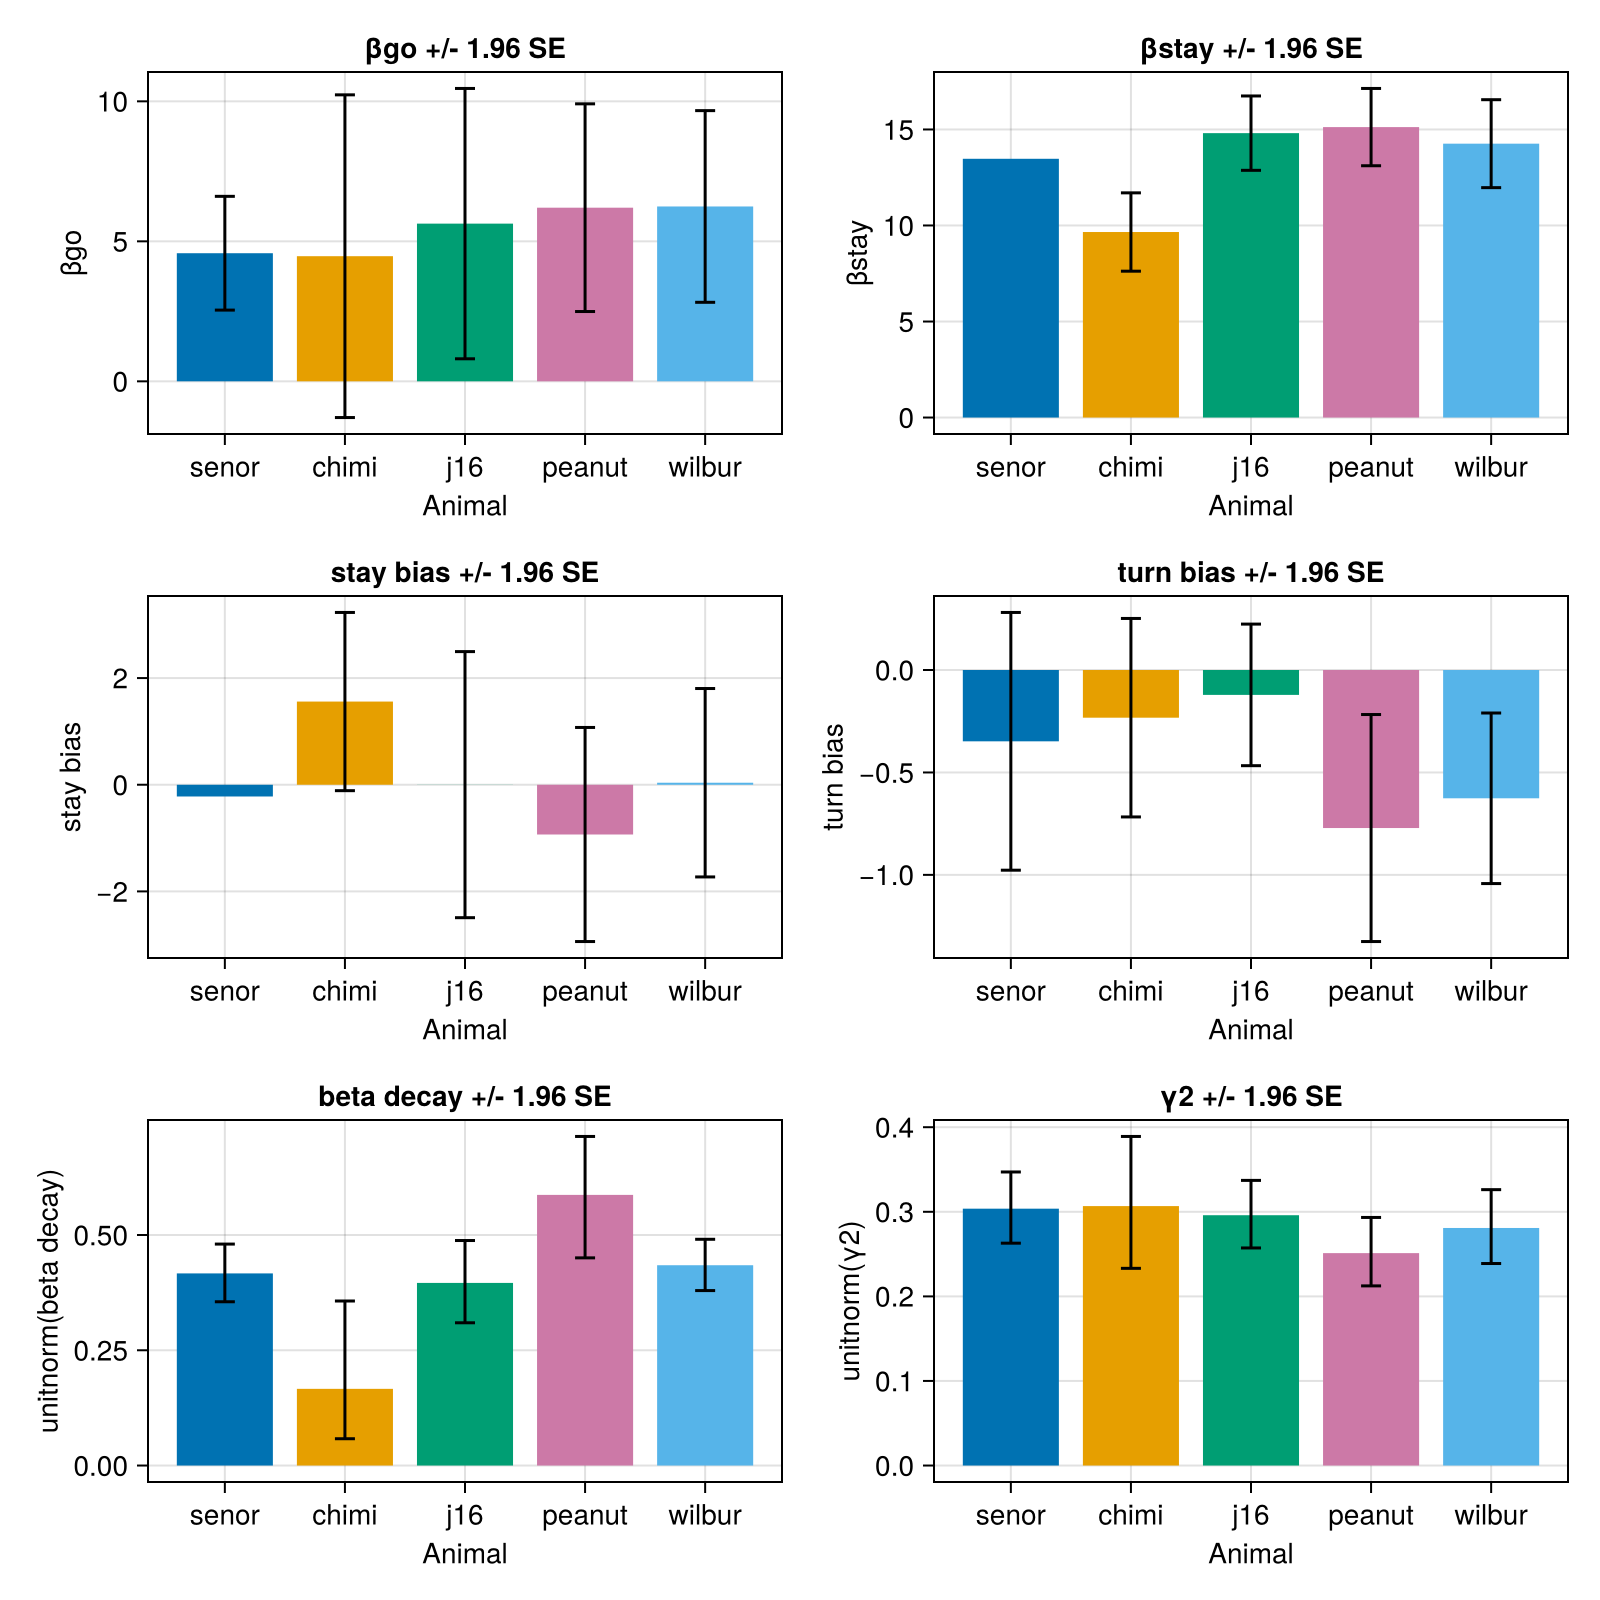

In [12]:
f = Figure(size=(800, 800))
colors = Makie.wong_colors()
ax = Axis(f[1,1], xlabel="Animal", ylabel="βgo", title="βgo +/- 1.96 SE", xticks=(1:5, animals))
barplot!(1:5, [rs_beta[i].betas[1] for i in 1:5], color=colors[1:5])
errorbars!(1:5, [rs_beta[i].betas[1] for i in 1:5], 1.96*[rs_beta[i].standarderrors[1] for i in 1:5], color=:black, whiskerwidth=10)

ax = Axis(f[1,2], xlabel="Animal", ylabel="βstay", title="βstay +/- 1.96 SE", xticks=(1:5, animals))
barplot!(1:5, [rs_beta[i].betas[2] for i in 1:5], color=colors[1:5])
errorbars!(1:5, [rs_beta[i].betas[2] for i in 1:5], 1.96*[rs_beta[i].standarderrors[2] for i in 1:5], color=:black, whiskerwidth=10)

ax = Axis(f[2,1], xlabel="Animal", ylabel="stay bias", title="stay bias +/- 1.96 SE", xticks=(1:5, animals))
barplot!(1:5, [rs_beta[i].betas[3] for i in 1:5], color=colors[1:5])
errorbars!(1:5, [rs_beta[i].betas[3] for i in 1:5], 1.96*[rs_beta[i].standarderrors[3] for i in 1:5], color=:black, whiskerwidth=10)

ax = Axis(f[2,2], xlabel="Animal", ylabel="turn bias", title="turn bias +/- 1.96 SE", xticks=(1:5, animals))
barplot!(1:5, [rs_beta[i].betas[4] for i in 1:5], color=colors[1:5])
errorbars!(1:5, [rs_beta[i].betas[4] for i in 1:5], 1.96*[rs_beta[i].standarderrors[4] for i in 1:5], color=:black, whiskerwidth=10)

ax = Axis(f[3,1], xlabel="Animal", ylabel="unitnorm(beta decay)", title="beta decay +/- 1.96 SE", xticks=(1:5, animals))
barplot!(1:5, unitnorm.([rs_beta[i].betas[5] for i in 1:5]), color=colors[1:5])
rangebars!(1:5,
    unitnorm.([rs_beta[i].betas[5] for i in 1:5] - 1.96*[rs_beta[i].standarderrors[5] for i in 1:5]), 
    unitnorm.([rs_beta[i].betas[5] for i in 1:5] + 1.96*[rs_beta[i].standarderrors[5] for i in 1:5]), 
    color=:black, whiskerwidth=10)

ax = Axis(f[3,2], xlabel="Animal", ylabel="unitnorm(γ2)", title="γ2 +/- 1.96 SE", xticks=(1:5, animals))
barplot!(1:5, unitnorm.([rs_beta[i].betas[6] for i in 1:5]), color=colors[1:5])
rangebars!(1:5,
    unitnorm.([rs_beta[i].betas[6] for i in 1:5] - 1.96*[rs_beta[i].standarderrors[6] for i in 1:5]), 
    unitnorm.([rs_beta[i].betas[6] for i in 1:5] + 1.96*[rs_beta[i].standarderrors[6] for i in 1:5]), 
    color=:black, whiskerwidth=10)
f

In [14]:
println("βgo pvalues")
println(rs_beta[1].pvalues[1])
println(rs_beta[2].pvalues[1])
println(rs_beta[3].pvalues[1])
println(rs_beta[4].pvalues[1])
println(rs_beta[5].pvalues[1])

βgo pvalues
4.9037826332322214e-5
0.13229661774230717
0.02821240448289084
0.002327360418302464
0.0010181174121022833


## Day Level

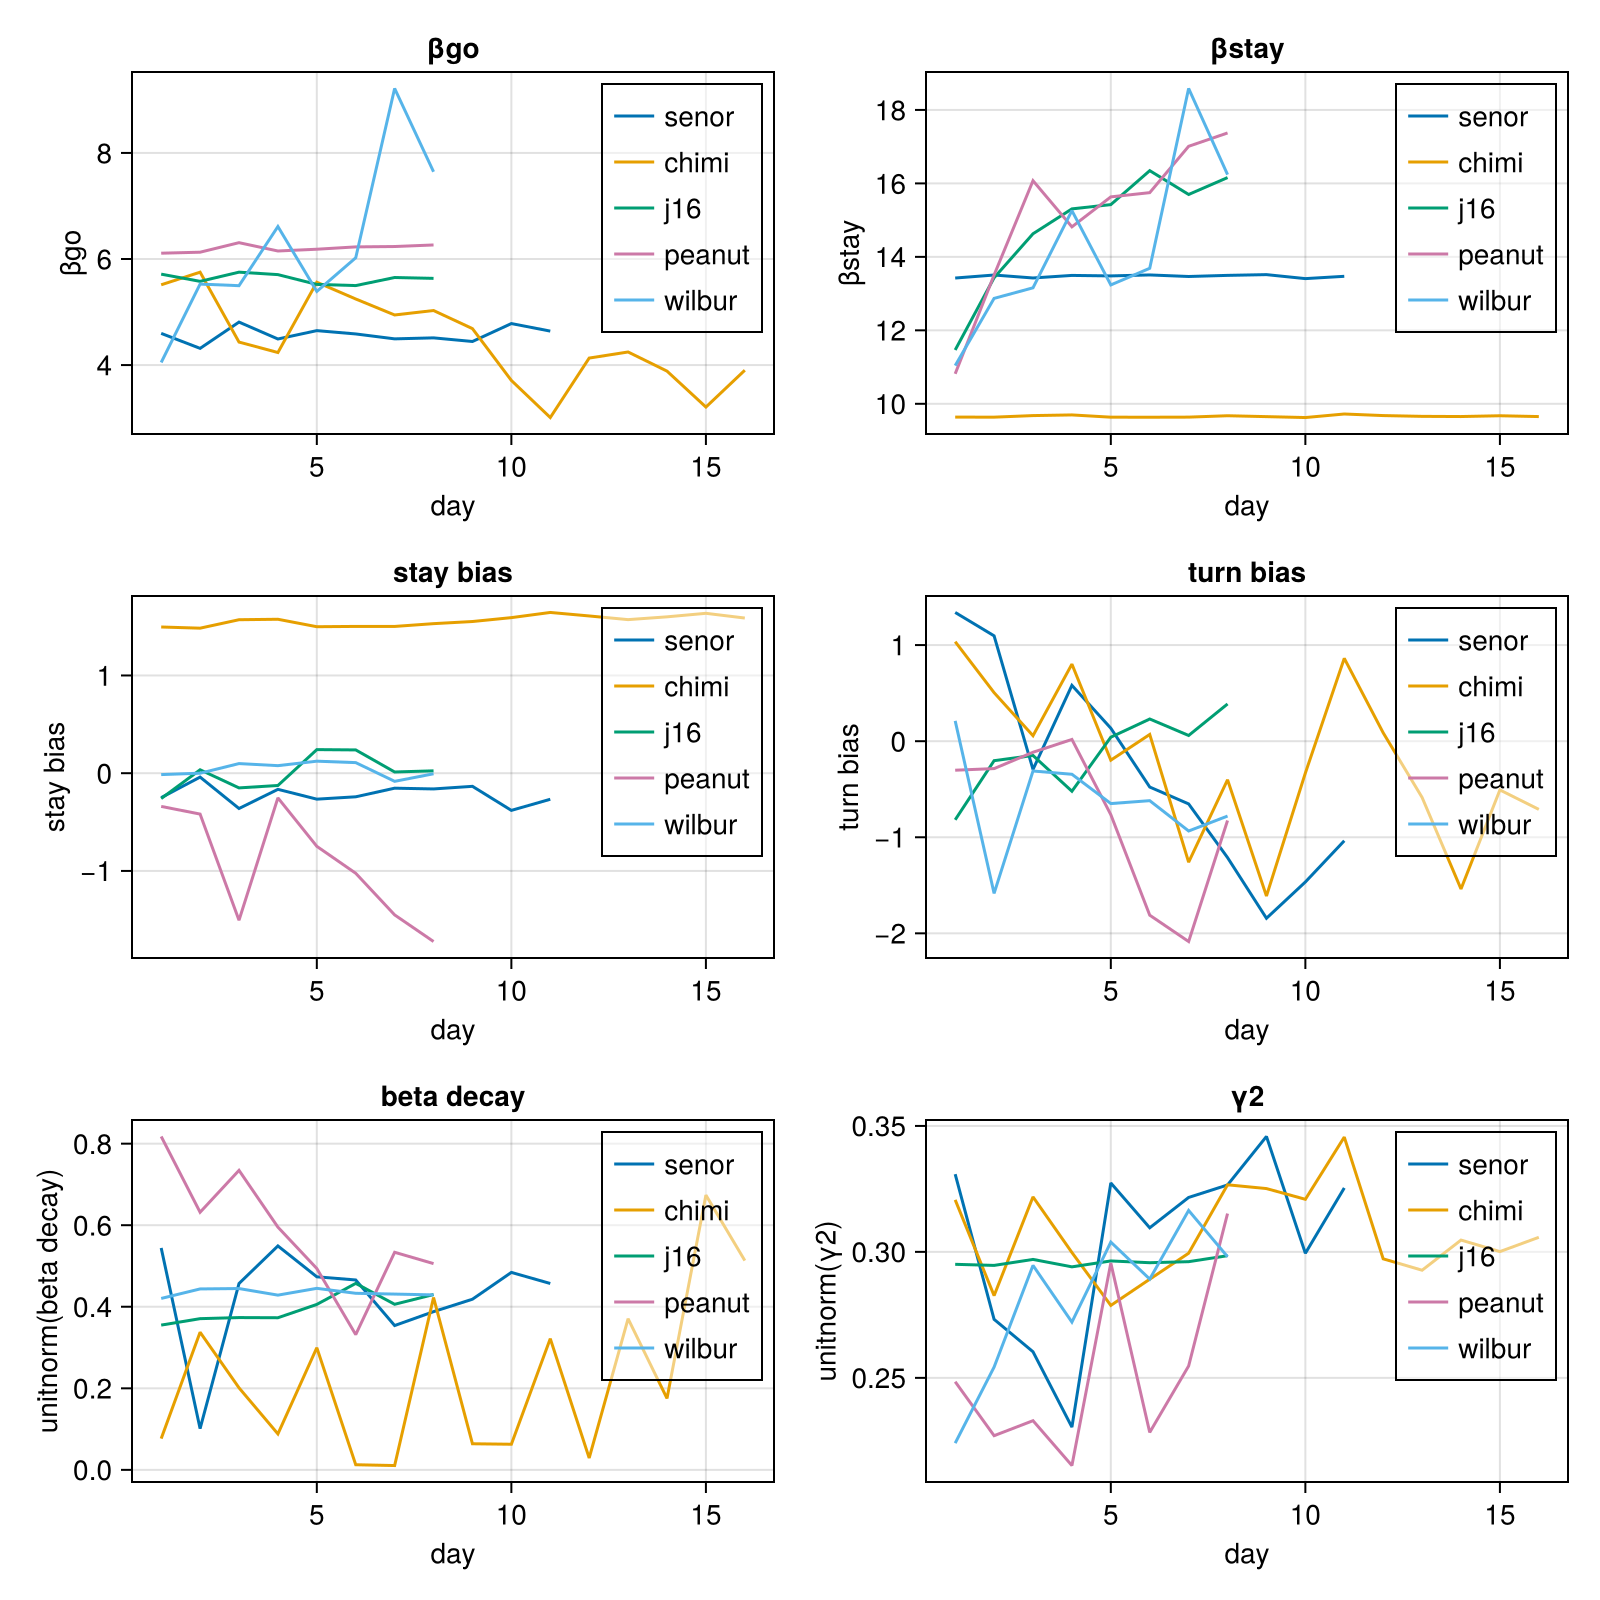

In [15]:
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.5))
f = Figure(size=(800, 800))
colors = Makie.wong_colors()
ax = Axis(f[1,1], xlabel="day", ylabel="βgo", title="βgo")
for i in 1:5
    lines!(rs_beta[i].x[:,1], color=colors[i], label=animals[i])
end
axislegend(;legend_kws...)

ax = Axis(f[1,2], xlabel="day", ylabel="βstay", title="βstay")
for i in 1:5
    lines!(rs_beta[i].x[:,2], color=colors[i], label=animals[i])
end
axislegend(;legend_kws...)

ax = Axis(f[2,1], xlabel="day", ylabel="stay bias", title="stay bias")
for i in 1:5
    lines!(rs_beta[i].x[:,3], color=colors[i], label=animals[i])
end
axislegend(;legend_kws...)

ax = Axis(f[2,2], xlabel="day", ylabel="turn bias", title="turn bias")
for i in 1:5
    lines!(rs_beta[i].x[:,4], color=colors[i], label=animals[i])
end
axislegend(;legend_kws...)

ax = Axis(f[3,1], xlabel="day", ylabel="unitnorm(beta decay)", title="beta decay")
for i in 1:5
    lines!(unitnorm.(rs_beta[i].x[:,5]), color=colors[i], label=animals[i])
end
axislegend(;legend_kws...)

ax = Axis(f[3,2], xlabel="day", ylabel="unitnorm(γ2)", title="γ2")
for i in 1:5
    lines!(unitnorm.(rs_beta[i].x[:,6]), color=colors[i], label=animals[i])
end
axislegend(;legend_kws...)
f

# Measures of Uncertainty

In [16]:
function zscore(x)
    (x .- mean(x)) ./ std(x)
end

zscore (generic function with 1 method)

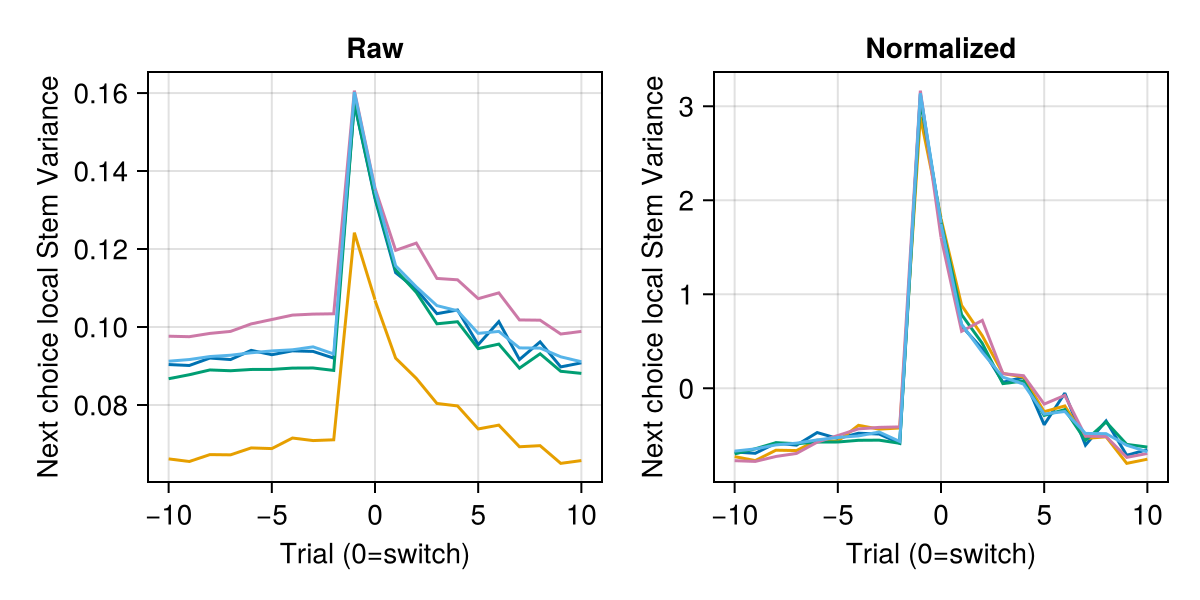

In [56]:
f = Figure(size=(600,300))
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.5))
colors = Makie.wong_colors()

ax1 = Axis(f[1,1], xlabel="Trial (0=switch)", ylabel="Next choice local Stem Variance", title="Raw")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    next_choice_local_variance_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :next_choice_local_variance => mean => :next_choice_local_variance)
    next_choice_local_variance_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :next_choice_local_variance => mean => :next_choice_local_variance)

    lines!(-next_choice_local_variance_by_day_q1_pre.n_pre_switch, next_choice_local_variance_by_day_q1_pre.next_choice_local_variance, color=colors[i])
    lines!(next_choice_local_variance_by_day_q1_post.n_post_switch, next_choice_local_variance_by_day_q1_post.next_choice_local_variance, color=colors[i])
end

ax1 = Axis(f[1,2], xlabel="Trial (0=switch)", ylabel="Next choice local Stem Variance", title="Normalized")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    next_choice_local_variance_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :next_choice_local_variance => mean => :next_choice_local_variance)
    next_choice_local_variance_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :next_choice_local_variance => mean => :next_choice_local_variance)

    adj = zscore(vcat(next_choice_local_variance_by_day_q1_pre.next_choice_local_variance, next_choice_local_variance_by_day_q1_post.next_choice_local_variance))
    lines!(-next_choice_local_variance_by_day_q1_pre.n_pre_switch, adj[1:11], color=colors[i])
    lines!(next_choice_local_variance_by_day_q1_post.n_post_switch, adj[12:end], color=colors[i])
end

f

Mean and variance update sizes around switches

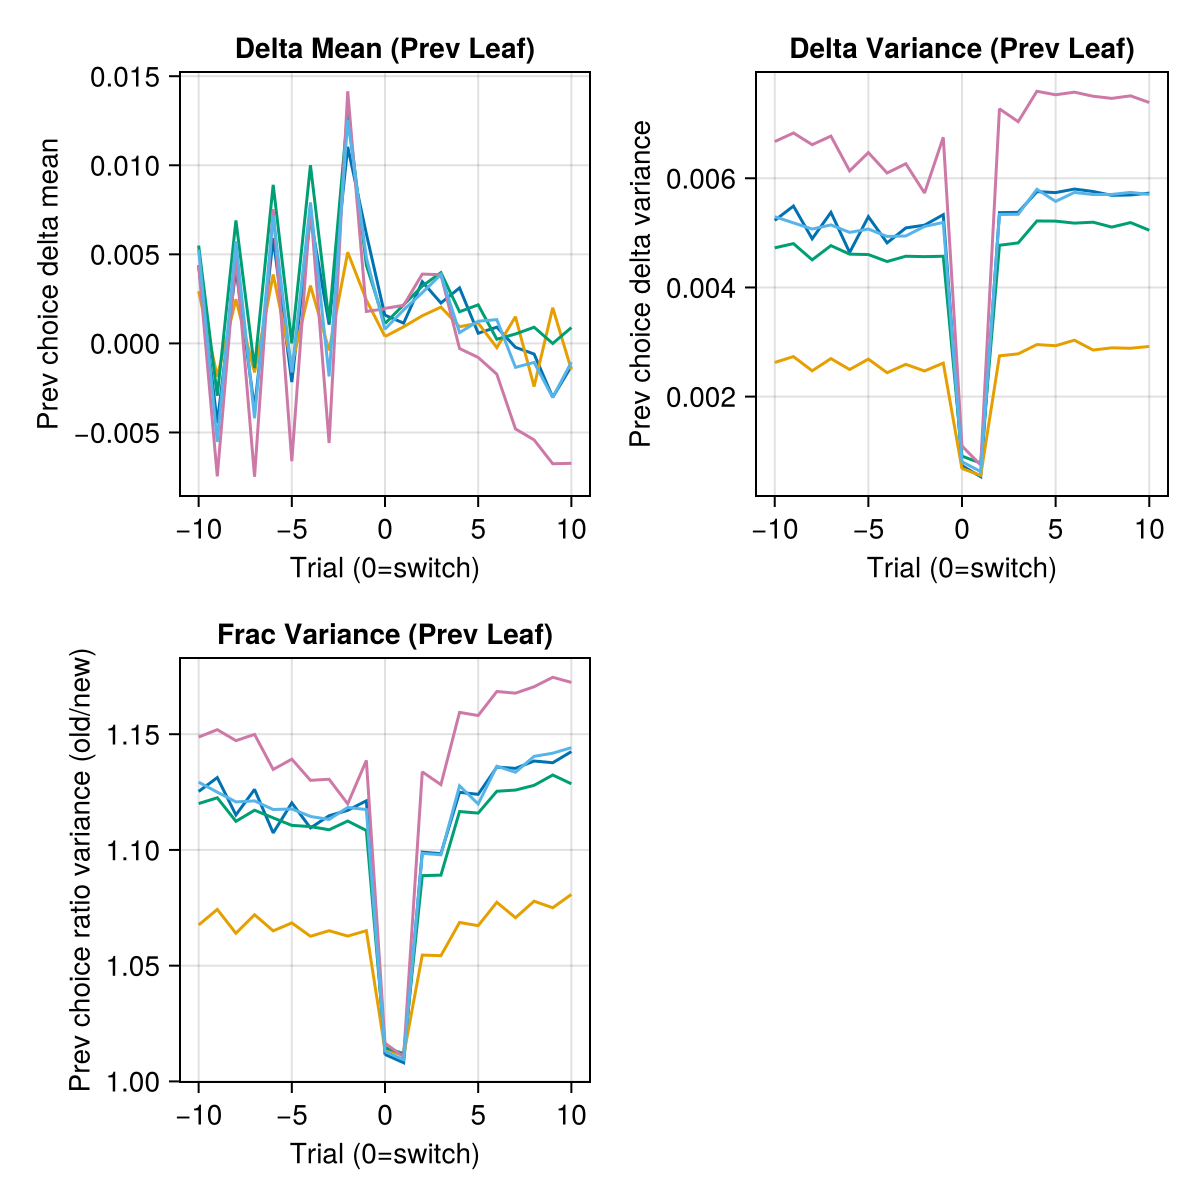

In [55]:
f = Figure(size=(600,600))
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.5))
colors = Makie.wong_colors()

ax1 = Axis(f[1,1], xlabel="Trial (0=switch)", ylabel="Prev choice delta mean", title="Delta Mean (Prev Leaf)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    prev_leaf_mu_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :prev_leaf_mu_delta => mean => :prev_leaf_mu_delta)
    prev_leaf_mu_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :prev_leaf_mu_delta => mean => :prev_leaf_mu_delta)

    lines!(-prev_leaf_mu_delta_by_day_q1_pre.n_pre_switch, prev_leaf_mu_delta_by_day_q1_pre.prev_leaf_mu_delta, color=colors[i])
    lines!(prev_leaf_mu_delta_by_day_q1_post.n_post_switch, prev_leaf_mu_delta_by_day_q1_post.prev_leaf_mu_delta, color=colors[i])
end

ax2 = Axis(f[1,2], xlabel="Trial (0=switch)", ylabel="Prev choice delta variance", title="Delta Variance (Prev Leaf)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    prev_leaf_var_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :prev_leaf_var_delta => mean => :prev_leaf_var_delta)
    prev_leaf_var_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :prev_leaf_var_delta => mean => :prev_leaf_var_delta)

    lines!(-prev_leaf_var_delta_by_day_q1_pre.n_pre_switch, prev_leaf_var_delta_by_day_q1_pre.prev_leaf_var_delta, color=colors[i])
    lines!(prev_leaf_var_delta_by_day_q1_post.n_post_switch, prev_leaf_var_delta_by_day_q1_post.prev_leaf_var_delta, color=colors[i])
end

ax3 = Axis(f[2,1], xlabel="Trial (0=switch)", ylabel="Prev choice ratio variance (old/new)", title="Frac Variance (Prev Leaf)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    prev_leaf_var_ratio_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :prev_leaf_var_ratio => mean => :prev_leaf_var_ratio)
    prev_leaf_var_ratio_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :prev_leaf_var_ratio => mean => :prev_leaf_var_ratio)

    lines!(-prev_leaf_var_ratio_by_day_q1_pre.n_pre_switch, prev_leaf_var_ratio_by_day_q1_pre.prev_leaf_var_ratio, color=colors[i])
    lines!(prev_leaf_var_ratio_by_day_q1_post.n_post_switch, prev_leaf_var_ratio_by_day_q1_post.prev_leaf_var_ratio, color=colors[i])
end

f

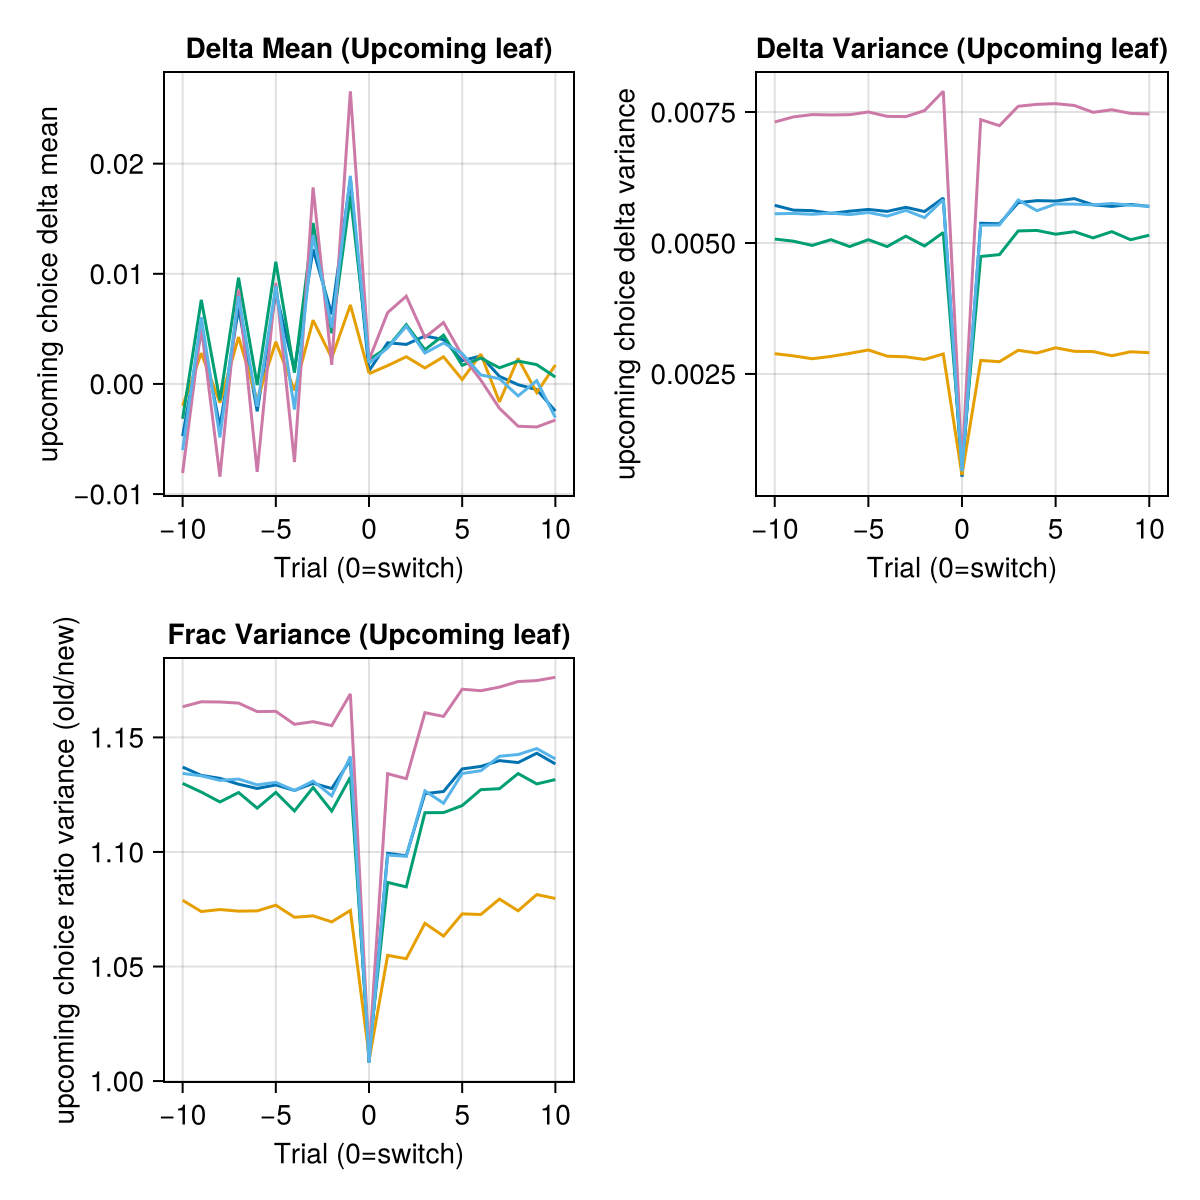

In [54]:
f = Figure(size=(600,600))
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.5))
colors = Makie.wong_colors()

ax1 = Axis(f[1,1], xlabel="Trial (0=switch)", ylabel="upcoming choice delta mean", title="Delta Mean (Upcoming leaf)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    upcoming_leaf_mu_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :upcoming_leaf_mu_delta => mean => :upcoming_leaf_mu_delta)
    upcoming_leaf_mu_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :upcoming_leaf_mu_delta => mean => :upcoming_leaf_mu_delta)

    lines!(-upcoming_leaf_mu_delta_by_day_q1_pre.n_pre_switch, upcoming_leaf_mu_delta_by_day_q1_pre.upcoming_leaf_mu_delta, color=colors[i])
    lines!(upcoming_leaf_mu_delta_by_day_q1_post.n_post_switch, upcoming_leaf_mu_delta_by_day_q1_post.upcoming_leaf_mu_delta, color=colors[i])
end

ax2 = Axis(f[1,2], xlabel="Trial (0=switch)", ylabel="upcoming choice delta variance", title="Delta Variance (Upcoming leaf)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    upcoming_leaf_var_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :upcoming_leaf_var_delta => mean => :upcoming_leaf_var_delta)
    upcoming_leaf_var_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :upcoming_leaf_var_delta => mean => :upcoming_leaf_var_delta)

    lines!(-upcoming_leaf_var_delta_by_day_q1_pre.n_pre_switch, upcoming_leaf_var_delta_by_day_q1_pre.upcoming_leaf_var_delta, color=colors[i])
    lines!(upcoming_leaf_var_delta_by_day_q1_post.n_post_switch, upcoming_leaf_var_delta_by_day_q1_post.upcoming_leaf_var_delta, color=colors[i])
end

ax3 = Axis(f[2,1], xlabel="Trial (0=switch)", ylabel="upcoming choice ratio variance (old/new)", title="Frac Variance (Upcoming leaf)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    upcoming_leaf_var_ratio_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :upcoming_leaf_var_ratio => mean => :upcoming_leaf_var_ratio)
    upcoming_leaf_var_ratio_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :upcoming_leaf_var_ratio => mean => :upcoming_leaf_var_ratio)

    lines!(-upcoming_leaf_var_ratio_by_day_q1_pre.n_pre_switch, upcoming_leaf_var_ratio_by_day_q1_pre.upcoming_leaf_var_ratio, color=colors[i])
    lines!(upcoming_leaf_var_ratio_by_day_q1_post.n_post_switch, upcoming_leaf_var_ratio_by_day_q1_post.upcoming_leaf_var_ratio, color=colors[i])
end

f

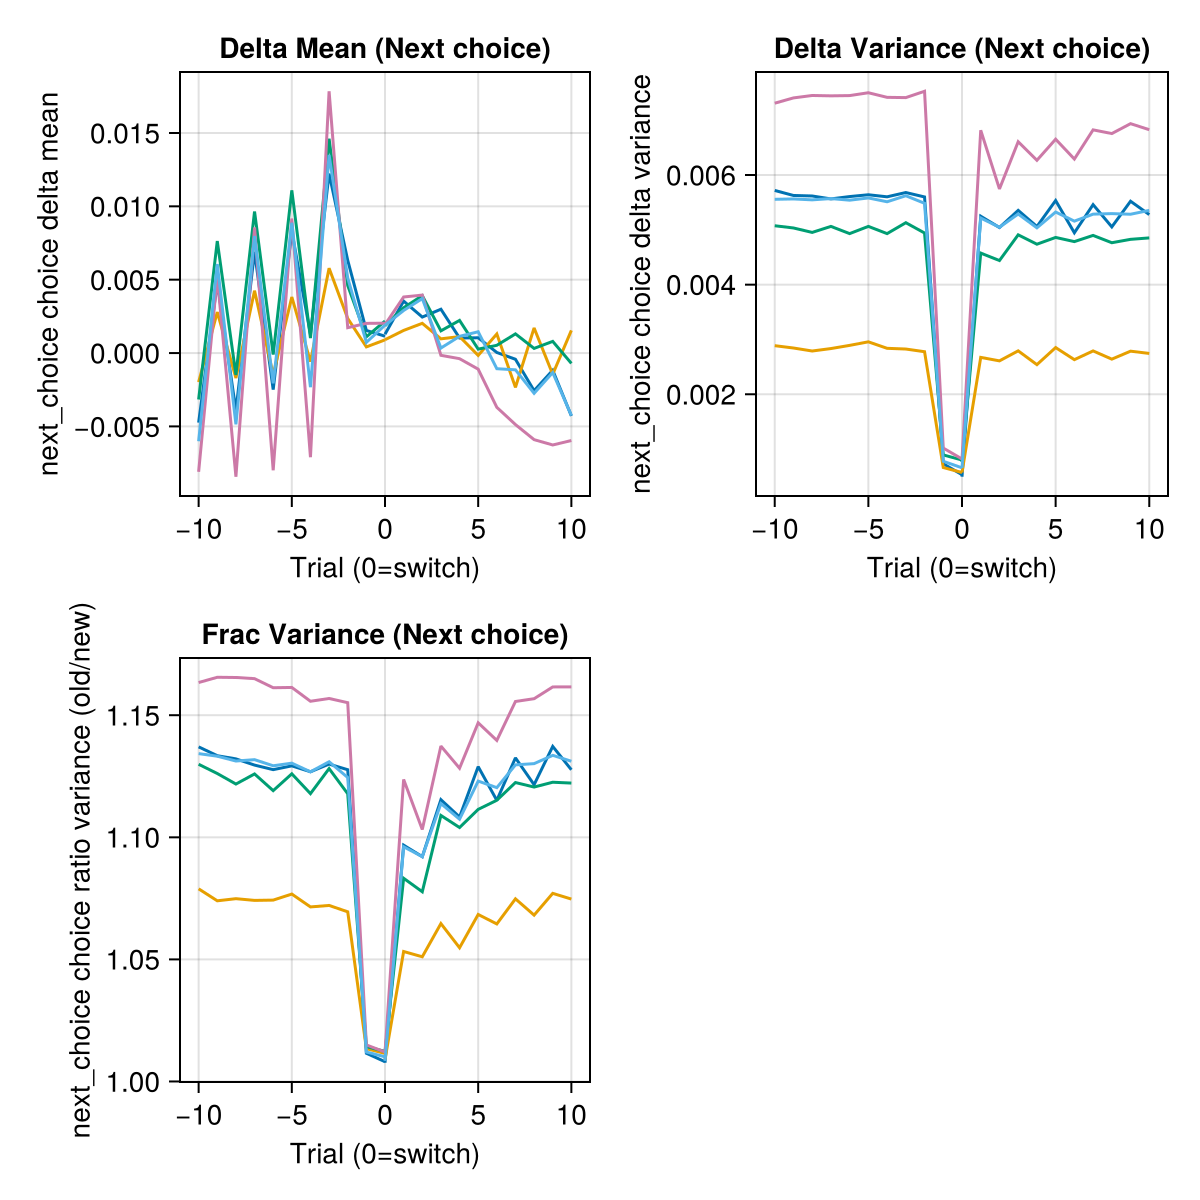

In [53]:
f = Figure(size=(600,600))
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.5))
colors = Makie.wong_colors()

ax1 = Axis(f[1,1], xlabel="Trial (0=switch)", ylabel="next_choice choice delta mean", title="Delta Mean (Next choice)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    next_choice_leaf_mu_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :next_choice_leaf_mu_delta => mean => :next_choice_leaf_mu_delta)
    next_choice_leaf_mu_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :next_choice_leaf_mu_delta => mean => :next_choice_leaf_mu_delta)

    lines!(-next_choice_leaf_mu_delta_by_day_q1_pre.n_pre_switch, next_choice_leaf_mu_delta_by_day_q1_pre.next_choice_leaf_mu_delta, color=colors[i])
    lines!(next_choice_leaf_mu_delta_by_day_q1_post.n_post_switch, next_choice_leaf_mu_delta_by_day_q1_post.next_choice_leaf_mu_delta, color=colors[i])
end

ax2 = Axis(f[1,2], xlabel="Trial (0=switch)", ylabel="next_choice choice delta variance", title="Delta Variance (Next choice)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    next_choice_leaf_var_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :next_choice_leaf_var_delta => mean => :next_choice_leaf_var_delta)
    next_choice_leaf_var_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :next_choice_leaf_var_delta => mean => :next_choice_leaf_var_delta)

    lines!(-next_choice_leaf_var_delta_by_day_q1_pre.n_pre_switch, next_choice_leaf_var_delta_by_day_q1_pre.next_choice_leaf_var_delta, color=colors[i])
    lines!(next_choice_leaf_var_delta_by_day_q1_post.n_post_switch, next_choice_leaf_var_delta_by_day_q1_post.next_choice_leaf_var_delta, color=colors[i])
end

ax3 = Axis(f[2,1], xlabel="Trial (0=switch)", ylabel="next_choice choice ratio variance (old/new)", title="Frac Variance (Next choice)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    next_choice_leaf_var_ratio_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :next_choice_leaf_var_ratio => mean => :next_choice_leaf_var_ratio)
    next_choice_leaf_var_ratio_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :next_choice_leaf_var_ratio => mean => :next_choice_leaf_var_ratio)

    lines!(-next_choice_leaf_var_ratio_by_day_q1_pre.n_pre_switch, next_choice_leaf_var_ratio_by_day_q1_pre.next_choice_leaf_var_ratio, color=colors[i])
    lines!(next_choice_leaf_var_ratio_by_day_q1_post.n_post_switch, next_choice_leaf_var_ratio_by_day_q1_post.next_choice_leaf_var_ratio, color=colors[i])
end

f

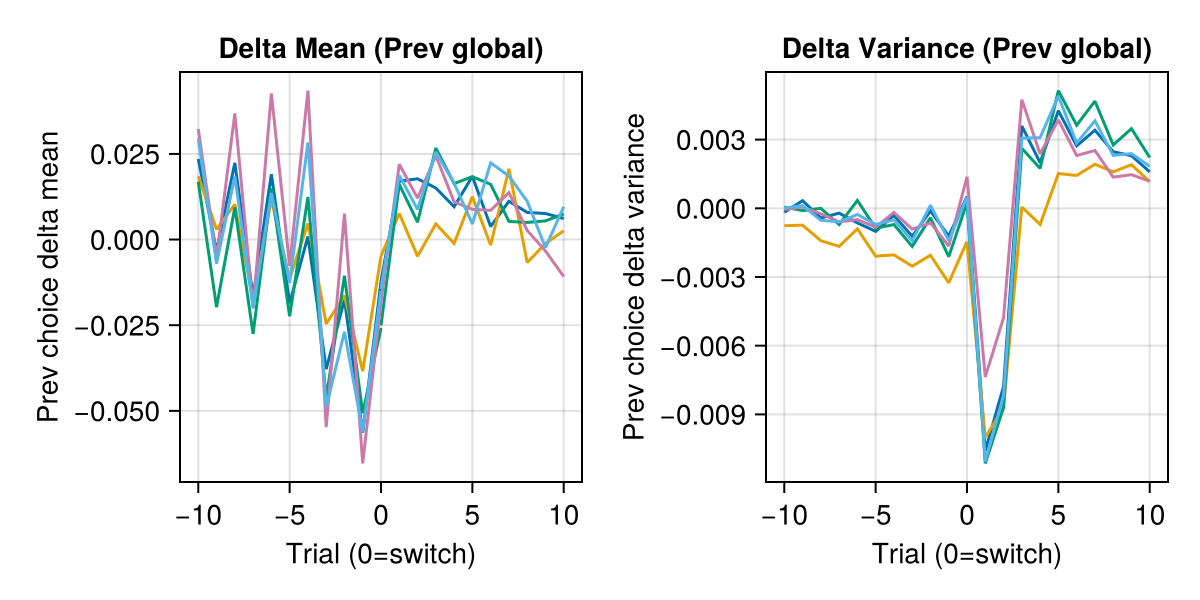

In [52]:
f = Figure(size=(600,300))
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.5))
colors = Makie.wong_colors()

ax1 = Axis(f[1,1], xlabel="Trial (0=switch)", ylabel="Prev choice delta mean", title="Delta Mean (Prev global)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    prev_global_mu_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :prev_global_mu_delta => mean => :prev_global_mu_delta)
    prev_global_mu_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :prev_global_mu_delta => mean => :prev_global_mu_delta)

    lines!(-prev_global_mu_delta_by_day_q1_pre.n_pre_switch, prev_global_mu_delta_by_day_q1_pre.prev_global_mu_delta, color=colors[i])
    lines!(prev_global_mu_delta_by_day_q1_post.n_post_switch, prev_global_mu_delta_by_day_q1_post.prev_global_mu_delta, color=colors[i])
end

ax2 = Axis(f[1,2], xlabel="Trial (0=switch)", ylabel="Prev choice delta variance", title="Delta Variance (Prev global)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    prev_global_var_delta_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :prev_global_var_delta => mean => :prev_global_var_delta)
    prev_global_var_delta_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :prev_global_var_delta => mean => :prev_global_var_delta)

    lines!(-prev_global_var_delta_by_day_q1_pre.n_pre_switch, prev_global_var_delta_by_day_q1_pre.prev_global_var_delta, color=colors[i])
    lines!(prev_global_var_delta_by_day_q1_post.n_post_switch, prev_global_var_delta_by_day_q1_post.prev_global_var_delta, color=colors[i])
end


f

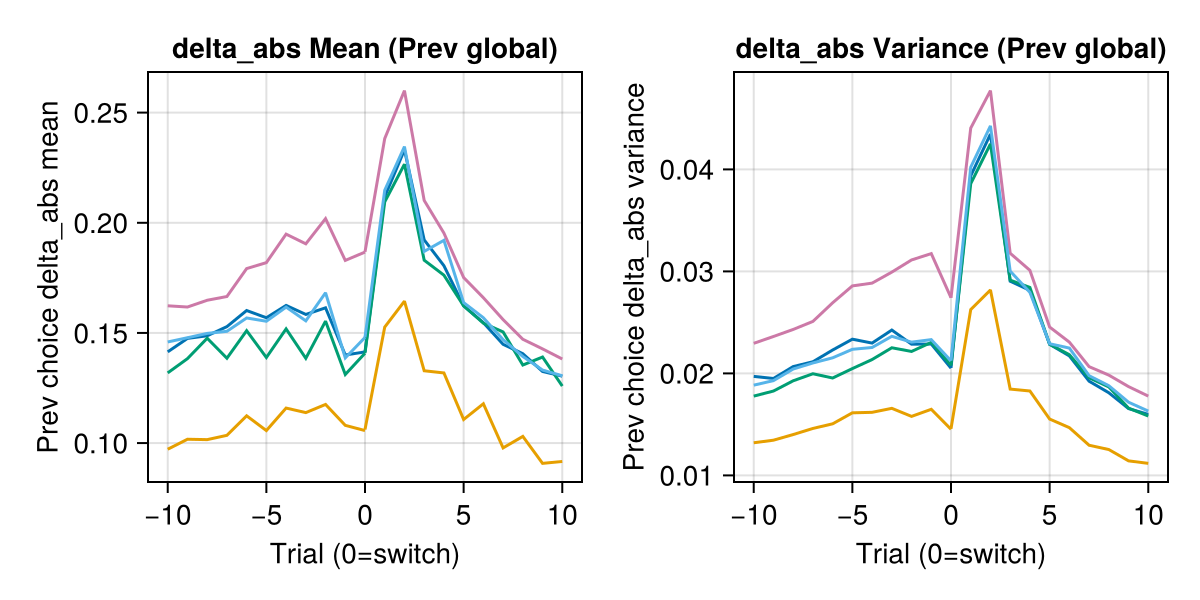

In [49]:
f = Figure(size=(600,300))
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.5))
colors = Makie.wong_colors()

ax1 = Axis(f[1,1], xlabel="Trial (0=switch)", ylabel="Prev choice delta_abs mean", title="delta_abs Mean (Prev global)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    prev_global_mu_delta_abs_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :prev_global_mu_delta_abs => mean => :prev_global_mu_delta_abs)
    prev_global_mu_delta_abs_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :prev_global_mu_delta_abs => mean => :prev_global_mu_delta_abs)

    lines!(-prev_global_mu_delta_abs_by_day_q1_pre.n_pre_switch, prev_global_mu_delta_abs_by_day_q1_pre.prev_global_mu_delta_abs, color=colors[i])
    lines!(prev_global_mu_delta_abs_by_day_q1_post.n_post_switch, prev_global_mu_delta_abs_by_day_q1_post.prev_global_mu_delta_abs, color=colors[i])
end

ax2 = Axis(f[1,2], xlabel="Trial (0=switch)", ylabel="Prev choice delta_abs variance", title="delta_abs Variance (Prev global)")
# vlines!([1,2,3,4], linestyle=:dash, color=:black)
for (i, animal) in enumerate(animals)
    q1 = qs_beta[i]

    prev_global_var_delta_abs_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :prev_global_var_delta_abs => mean => :prev_global_var_delta_abs)
    prev_global_var_delta_abs_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 11) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :prev_global_var_delta_abs => mean => :prev_global_var_delta_abs)

    lines!(-prev_global_var_delta_abs_by_day_q1_pre.n_pre_switch, prev_global_var_delta_abs_by_day_q1_pre.prev_global_var_delta_abs, color=colors[i])
    lines!(prev_global_var_delta_abs_by_day_q1_post.n_post_switch, prev_global_var_delta_abs_by_day_q1_post.prev_global_var_delta_abs, color=colors[i])
end


f

# Comparison with HMM

In [135]:
rs_independentsamedist = [load("$(filepath)/results/hmm_independentsamedist_biases/hmm_independentsamedist_stay_turn_γ2_$(animal).jld2", "results") for animal in animals];
rs_base = [load("$(filepath)/results/hmm_biases/hmm_stay_turn_γ2_$(animal).jld2", "results") for animal in animals];

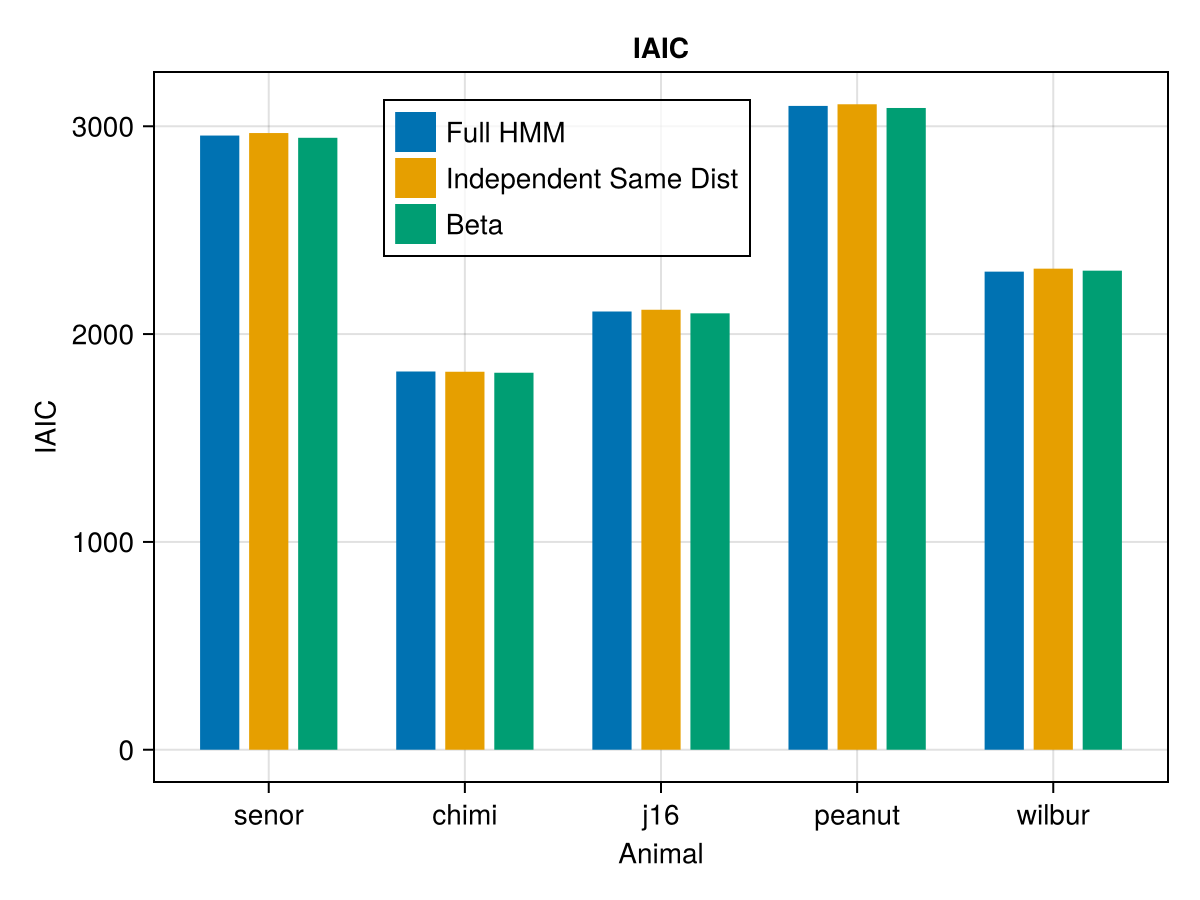

In [203]:
iaics_base = iaic.(rs_base)
iaics_independentsamedist = iaic.(rs_independentsamedist)
iaics_beta = iaic.(rs_beta)

f = Figure()
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.75))
colors = Makie.wong_colors()
ax = Axis(f[1,1], xlabel="Animal", ylabel="IAIC", title="IAIC", xticks=([2,6,10,14,18], animals))
for i in 1:5
    x = (1:3) .+ ((i-1) * 4)
    barplot!(x[1], iaics_base[i], color=colors[1], label=["Full HMM"], width=1.0)
    barplot!(x[2], iaics_independentsamedist[i], color=colors[2], label=["Independent Same Dist"], width=1.0)
    barplot!(x[3], iaics_beta[i], color=colors[3], label=["Beta"], width=1.0)
end
axislegend(merge=true; legend_kws..., position = (0.35, 0.97))
f

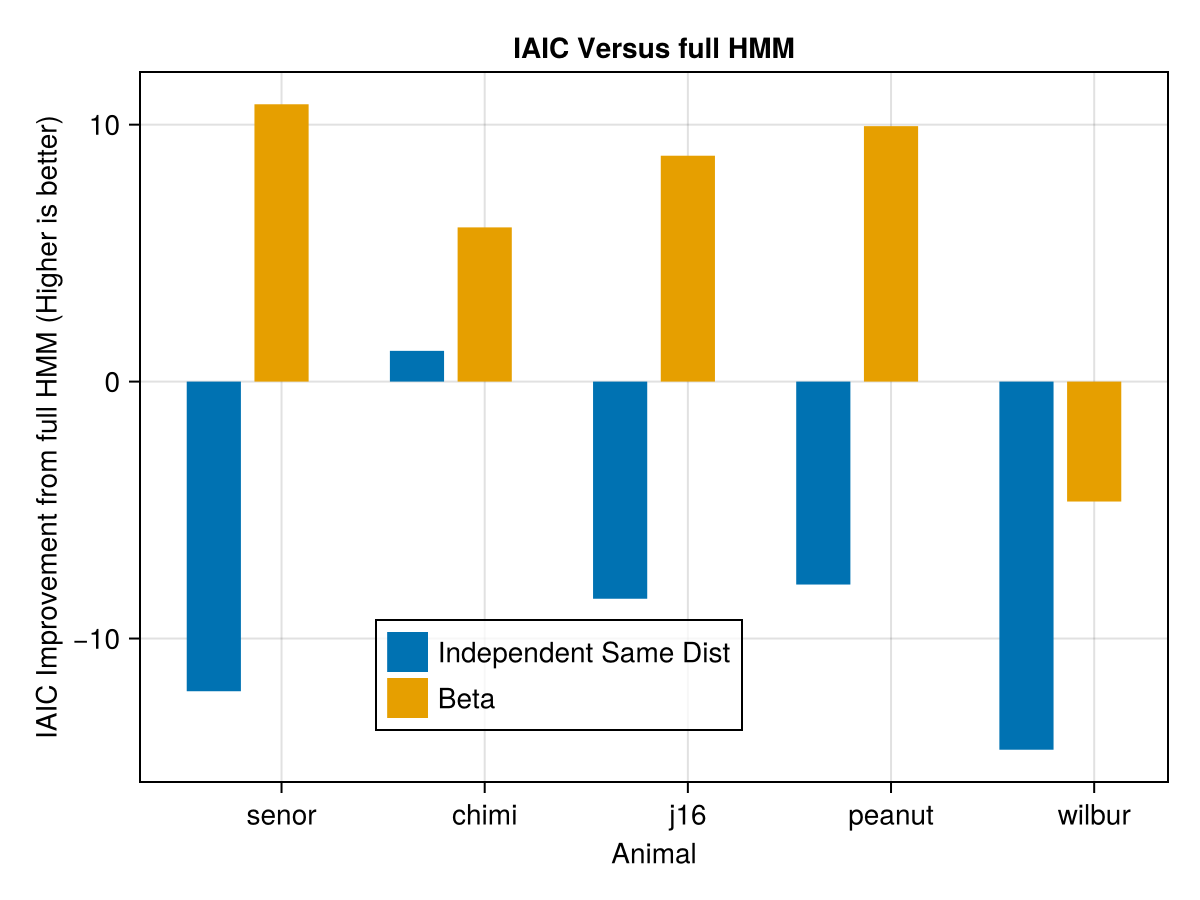

In [204]:
iaics_base = iaic.(rs_base)
iaics_independentsamedist = iaic.(rs_independentsamedist)
iaics_beta = iaic.(rs_beta)

f = Figure()
legend_kws = Dict(:backgroundcolor=>(1,1,1,0.75))
colors = Makie.wong_colors()
ax = Axis(f[1,1], xlabel="Animal", ylabel="IAIC Improvement from full HMM (Higher is better)", title="IAIC Versus full HMM", xticks=([2,5,8,11,14], animals))
for i in 1:5
    x = (1:2) .+ ((i-1) * 3)
    barplot!(x[1], iaics_base[i] - iaics_independentsamedist[i], color=colors[1], label=["Independent Same Dist"], width=1.0)
    barplot!(x[2], iaics_base[i] - iaics_beta[i], color=colors[2], label=["Beta"], width=1.0)
    # barplot!(x[2], iaics_independentsamedist[i], color=colors[2], label=["Independent Same Dist"], width=1.0)
    # barplot!(x[3], iaics_beta[i], color=colors[3], label=["Beta"], width=1.0)
end
axislegend(merge=true; legend_kws..., position = (0.35, 0.07))
f

## Versus Q-Learning